In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import transforms

import tensorflow as tf
from tensorflow.keras import layers, models

#Task 1: Acquire the data

## Load data

In [3]:
# Load training set (60K images)
X_tr = np.load("/content/drive/MyDrive/kmnist/kmnist-train-imgs.npz")["arr_0"]
y_tr = np.load("/content/drive/MyDrive/kmnist/kmnist-train-labels.npz")["arr_0"]

# Load test set (10K images)
X_te = np.load("/content/drive/MyDrive/kmnist/kmnist-test-imgs.npz")["arr_0"]
y_te = np.load("/content/drive/MyDrive/kmnist/kmnist-test-labels.npz")["arr_0"]

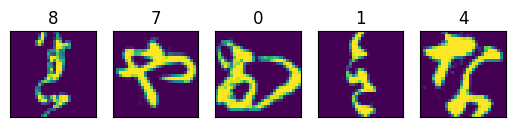

In [4]:
# plot some examples
def plot_examples(X, y):
    for i, (img, label) in enumerate(zip(X[:5].reshape(5, 28, 28), y[:5])):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(label)


plot_examples(X_tr, y_tr)

##EDA

In [5]:
# Print the shapes of dataset to see the size of the datasets:
print(X_tr.shape)
print(y_tr.shape)
print(X_te.shape)
print(y_te.shape)

print(X_tr[0].shape)
print(X_te[0].shape)


#print head of each file to see what kind of data we have:
print(X_tr[0][0])
#print(y_tr)
# print(X_te[0])
# print(y_te[0])

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
(28, 28)
(28, 28)
[  0   0   0   0   0   0   0   0  10   7 233  86   0   0  32  99   0   0
   0   0   0   0   0   0   0   0   0   0]


In [6]:
#split the test set to train and valid:
X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.2, random_state=42)

In [7]:
# flatten the datasets:
X_train = X_tr.reshape(X_tr.shape[0], -1)
X_valid = X_val.reshape(X_val.shape[0], -1)
X_test = X_te.reshape(X_te.shape[0], -1)

y_train = y_tr
y_valid = y_val
y_test = y_te

In [8]:
# Standardization:
mean_X_train = np.mean(X_train, axis=0)
std_X_train = np.std(X_train, axis=0)

X_train = (X_train - mean_X_train) / std_X_train
X_valid = (X_valid - mean_X_train) / std_X_train
X_test = (X_test - mean_X_train) / std_X_train

In [9]:
cov = np.dot(X_train.T, X_train) / X_train.shape[0]
U,S,V = np.linalg.svd(cov)
#X_rot = np.dot(X_train, U) # decorrelate the data

#reduce X
X_train_reduced = np.dot(X_train, U[:,:100])
# Project validation and test sets using the same U
X_val_reduced = np.dot(X_valid, U[:, :100])
X_test_reduced = np.dot(X_test, U[:, :100])

In [10]:
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

print(y_train.shape)
print(y_valid.shape)
print(y_test.shape)

(48000, 784)
(12000, 784)
(10000, 784)
(48000,)
(12000,)
(10000,)


In [11]:
# check to see if there are any missing values both in data and labels
print(np.isnan(X_train).any())
print(np.isnan(X_valid).any())
print(np.isnan(X_test).any())

print(np.isnan(y_train).any())
print(np.isnan(y_valid).any())
print(np.isnan(y_test).any())


# check to see if labels are any other value except for numbers form 0 to 9
print(np.unique(y_train))
print(np.unique(y_valid))
print(np.unique(y_test))


False
False
False
False
False
False
[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


#Task 2: Implement an MLP to classify image data

In [12]:
class MLP:
  def __init__(self, input_size, num_hidden_layers, hidden_size, output_size, activation="relu", l2_lambda=0.0):
    # self.input_size = input_size
    self.num_hidden_layers = num_hidden_layers
    self.hidden_size = hidden_size
    self.output_size = output_size
    self.activation_func = self._get_activation(activation)
    self.activation_derivative = self._get_activation_derivative(activation)
    self.l2_lambda = l2_lambda

    # initialize the weights and biases
    self.weights = []
    self.biases = []

    total = [input_size] + [hidden_size] * num_hidden_layers + [output_size]
    for i in range(len(total) - 1):
      self.weights.append(np.random.randn(total[i], total[i+1]) * 0.01)
      self.biases.append(np.zeros((1, total[i+1])))


  def _get_activation(self, activation):
    if activation == "relu":
      return lambda x: np.maximum(0, x)
    elif activation == "sigmoid":
      return lambda x: 1 / (1 + np.exp(-x))
    elif activation == "leaky_relu":
      return lambda x: np.where(x > 0, x, x * 0.01)
    else:
      raise ValueError("Invalid activation function")

  def _get_activation_derivative(self, activation):
    if activation == "relu":
      return lambda x: np.where(x > 0, 1, 0)
    elif activation == "sigmoid":
      return lambda x: self._get_activation("sigmoid")(x) * (1 - self._get_activation("sigmoid")(x))
    elif activation == "leaky_relu":
      return lambda x: np.where(x > 0, 1, 0.01)
    else:
      raise ValueError("Invalid activation function")

  def _softmax(self, x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


  def forward(self, X):
    # forward hidden layers with selective activation function
    activations = [X]
    for i in range(self.num_hidden_layers):
      z = np.dot(activations[i], self.weights[i]) + self.biases[i]
      a = self.activation_func(z)
      activations.append(a)

    # forward output layer with softmax to have
    z = np.dot(activations[-1], self.weights[-1]) + self.biases[-1]
    a = self._softmax(z)
    activations.append(a)

    # print(activations[-1])
    # print(activations[-1].shape)

    return activations

  def backward(self, X, y, activations, learning_rate):
    grads_w = [None] * len(self.weights)
    grads_b = [None] * len(self.weights)

    # Get one hot endcoded y labels:
    y_hotEncoded = np.eye(self.output_size)[y]

    # back prop for output layer
    a = activations[-1]
    delta = a - y_hotEncoded
    grads_w[-1] = np.dot(activations[-2].T, delta) / X.shape[0]
    grads_b[-1] = np.sum(delta, axis=0, keepdims=True) / X.shape[0]

    # back prop for hidden layers: (loop from 0 until last hidden layer backwards)
    for i in range(self.num_hidden_layers -1 , -1, -1):
      w_next = self.weights[i+1]
      a_hidden = activations[i+1]
      delta = np.dot(delta, w_next.T) * self.activation_derivative(a_hidden)
      grads_w[i] = np.dot(activations[i].T, delta) / X.shape[0]
      grads_b[i] = np.sum(delta, axis=0, keepdims=True) / X.shape[0]

    # return grads_w, grads_b
    if self.l2_lambda > 0:
      for i in range(len(self.weights)):
        grads_w[i] += self.l2_lambda * self.weights[i]

    for i in range(len(self.weights)):
      self.weights[i] -= learning_rate * grads_w[i]
      self.biases[i] -= learning_rate * grads_b[i]

    return grads_w


  def fit(self, X, y, X_val=None, y_val=None, lr = 0.1, epochs=100, batch_size=32, optimizer="sgd"):
    train_accs = []
    val_accs = []

    # Variables to store the best model state
    best_val_acc = -1
    best_epoch = 0
    best_weights = None
    best_biases = None

    for epoch in range(epochs):
      # shuffle the data to avoid having model memorize them.
      indices = np.random.permutation(X.shape[0])
      X_shuffled = X[indices]
      y_shuffled = y[indices]
      # X_shuffled = X[np.random.permutation(X.shape[0])]
      # y_shuffled = y[np.random.permutation(y.shape[0])]


      for i in range(0, X.shape[0], batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        # Call the forward and backwards
        activations = self.forward(X_batch)
        self.backward(X_batch, y_batch, activations, lr)


      # To track the accuracy at each epoch and plot:
      train_preds = self.predict(X)
      train_acc = self.evaluate_acc(y, train_preds)
      train_accs.append(train_acc)

      val_preds = self.predict(X_val)
      val_acc = self.evaluate_acc(y_val, val_preds)
      val_accs.append(val_acc)
      print(f"Epoch {epoch+1}/{epochs}, Training Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")


      # Check if this is the best validation accuracy so far
      if val_acc > best_val_acc:
          best_val_acc = val_acc
          best_epoch = epoch + 1
          # Store copies of best parameters
          best_weights = [w.copy() for w in self.weights]
          best_biases = [b.copy() for b in self.biases]


    self.weights = [w.copy() for w in best_weights]
    self.biases = [b.copy() for b in best_biases]

    # Plot the accuracies after training completes
    plt.figure()
    plt.plot(range(1, epochs+1), train_accs, label='Train Accuracy')
    valid_val_accs = [acc for acc in val_accs if acc is not None]
    plt.plot(range(1, epochs+1), valid_val_accs, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.show()


    print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")



  def predict(self, X):
    out = self.forward(X)[-1]
    return np.argmax(out, axis=1)

  def evaluate_acc(self, y_true, y_pred):
    return np.mean(y_true == y_pred)

  def compute_loss(self, y_true, y_pred_proba):
    "explicitly computes loss for gradient checking"
    N = y_true.shape[0]
    y_one_hot = np.eye(self.output_size)[y_true]  # One-hot encode labels
    log_probs = np.log(y_pred_proba + 1e-10)      # Add epsilon for stability
    loss = -np.sum(y_one_hot * log_probs) / N

    # optional L2 regularization
    if self.l2_lambda > 0:
        l2_term = sum(np.sum(w ** 2) for w in self.weights)
        loss += (self.l2_lambda / 2) * l2_term

    return loss

  def gradient_check_full_layer(self, X, y, epsilon=1e-5, layer_idx=0):
    """
    Performs gradient checking for all weights in a specific layer of the MLP.
    """

    for i, W in enumerate(self.weights):
        print(f"Layer {i} weights shape: {W.shape}")

    original_W = self.weights[layer_idx]
    numerical_grad = np.zeros_like(original_W)

    for i in range(original_W.shape[0]):
        for j in range(original_W.shape[1]):
            # Make a copy for positive perturbation
            W_plus = original_W.copy()
            W_plus[i, j] += epsilon

            # Make a copy for negative perturbation
            W_minus = original_W.copy()
            W_minus[i, j] -= epsilon

            # Temporarily set perturbed weights and compute loss
            self.weights[layer_idx] = W_plus
            loss_plus = self.compute_loss(y, self.forward(X)[-1])

            self.weights[layer_idx] = W_minus
            loss_minus = self.compute_loss(y, self.forward(X)[-1])

            # Numerical gradient
            numerical_grad[i, j] = (loss_plus - loss_minus) / (2 * epsilon)

    # Restore original weights
    self.weights[layer_idx] = original_W.copy()

    # Get analytical gradient via backprop
    activations = self.forward(X)
    grads_w = self.backward(X, y, activations, learning_rate=0.0)
    analytical_grad = grads_w[layer_idx]

    if self.l2_lambda > 0:
        analytical_grad += self.l2_lambda * original_W

    # Relative error
    num = np.linalg.norm(numerical_grad - analytical_grad)
    denom = np.linalg.norm(numerical_grad) + np.linalg.norm(analytical_grad) + 1e-10
    relative_error = num / denom

    print(f"Relative error for layer {layer_idx}: {relative_error:.10e}")

    if relative_error < 1e-7:
        print(f"Gradient check passed for layer {layer_idx}.")
    else:
        print(f"Gradient check failed for layer {layer_idx}.")
    return relative_error



#Task 3: Run the experiments

##3.1: 3 different models:

###3.1.1: MLP with no hidden layer

Layer 0 weights shape: (784, 10)
Relative error for layer 0: 6.2694621176e-10
Gradient check passed for layer 0.
Epoch 1/20, Training Accuracy: 0.8115, Validation Accuracy: 0.8054
Epoch 2/20, Training Accuracy: 0.8206, Validation Accuracy: 0.8150
Epoch 3/20, Training Accuracy: 0.8222, Validation Accuracy: 0.8135
Epoch 4/20, Training Accuracy: 0.8277, Validation Accuracy: 0.8202
Epoch 5/20, Training Accuracy: 0.8306, Validation Accuracy: 0.8205
Epoch 6/20, Training Accuracy: 0.8318, Validation Accuracy: 0.8203
Epoch 7/20, Training Accuracy: 0.8319, Validation Accuracy: 0.8201
Epoch 8/20, Training Accuracy: 0.8340, Validation Accuracy: 0.8203
Epoch 9/20, Training Accuracy: 0.8355, Validation Accuracy: 0.8206
Epoch 10/20, Training Accuracy: 0.8350, Validation Accuracy: 0.8205
Epoch 11/20, Training Accuracy: 0.8361, Validation Accuracy: 0.8204
Epoch 12/20, Training Accuracy: 0.8364, Validation Accuracy: 0.8190
Epoch 13/20, Training Accuracy: 0.8390, Validation Accuracy: 0.8198
Epoch 14/20,

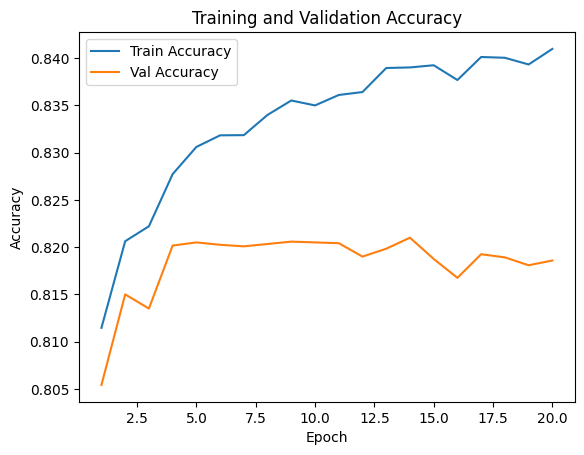

Best validation accuracy: 0.8210 at epoch 14
Test Accuracy for the best epoch: 0.6952


In [13]:
mlp_no_hidden = MLP(input_size=784, num_hidden_layers=0, hidden_size=0, output_size=10, activation="relu")

# Run gradient check before training
X_small = X_train[:10]
y_small = y_train[:10]

for i in range(mlp_no_hidden.num_hidden_layers + 1):
    mlp_no_hidden.gradient_check_full_layer(X_small, y_small, layer_idx=i)

mlp_no_hidden.fit(X_train, y_train, X_valid, y_valid, lr=0.1, epochs=20, batch_size=784, optimizer="sgd")

best_weights = mlp_no_hidden.weights
best_biases = mlp_no_hidden.biases

test_preds = mlp_no_hidden.predict(X_test)
test_acc = mlp_no_hidden.evaluate_acc(y_test, test_preds)
print(f"Test Accuracy for the best epoch: {test_acc:.4f}")

test acuracies for mlp with **no hidden** layer and **ReLU activation**, batch size 784 and 20 epochs: \\
***69.29%***

###3.1.2: MLP with a single hidden layer having ReLU activations

Layer 0 weights shape: (784, 32)
Layer 1 weights shape: (32, 10)
Relative error for layer 0: 3.7395164408e-09
Gradient check passed for layer 0.
Layer 0 weights shape: (784, 32)
Layer 1 weights shape: (32, 10)
Relative error for layer 1: 6.0758317542e-10
Gradient check passed for layer 1.
Epoch 1/20, Training Accuracy: 0.8977, Validation Accuracy: 0.8839
Epoch 2/20, Training Accuracy: 0.9245, Validation Accuracy: 0.9018
Epoch 3/20, Training Accuracy: 0.9353, Validation Accuracy: 0.9107
Epoch 4/20, Training Accuracy: 0.9445, Validation Accuracy: 0.9156
Epoch 5/20, Training Accuracy: 0.9462, Validation Accuracy: 0.9143
Epoch 6/20, Training Accuracy: 0.9544, Validation Accuracy: 0.9116
Epoch 7/20, Training Accuracy: 0.9545, Validation Accuracy: 0.9127
Epoch 8/20, Training Accuracy: 0.9576, Validation Accuracy: 0.9108
Epoch 9/20, Training Accuracy: 0.9576, Validation Accuracy: 0.9097
Epoch 10/20, Training Accuracy: 0.9583, Validation Accuracy: 0.9093
Epoch 11/20, Training Accuracy: 0.9633,

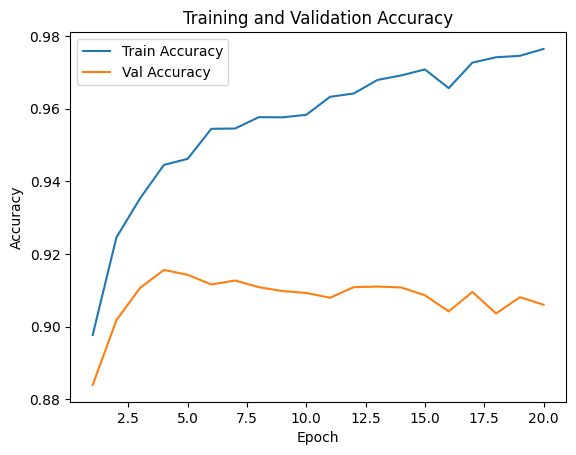

Best validation accuracy: 0.9156 at epoch 4
Test Accuracy for the best epoch with 32 hidden units: 0.8198
Layer 0 weights shape: (784, 64)
Layer 1 weights shape: (64, 10)
Relative error for layer 0: 4.3573614488e-09
Gradient check passed for layer 0.
Layer 0 weights shape: (784, 64)
Layer 1 weights shape: (64, 10)
Relative error for layer 1: 6.6512087770e-10
Gradient check passed for layer 1.
Epoch 1/20, Training Accuracy: 0.9129, Validation Accuracy: 0.9003
Epoch 2/20, Training Accuracy: 0.9399, Validation Accuracy: 0.9156
Epoch 3/20, Training Accuracy: 0.9554, Validation Accuracy: 0.9259
Epoch 4/20, Training Accuracy: 0.9620, Validation Accuracy: 0.9266
Epoch 5/20, Training Accuracy: 0.9709, Validation Accuracy: 0.9300
Epoch 6/20, Training Accuracy: 0.9776, Validation Accuracy: 0.9322
Epoch 7/20, Training Accuracy: 0.9803, Validation Accuracy: 0.9321
Epoch 8/20, Training Accuracy: 0.9831, Validation Accuracy: 0.9312
Epoch 9/20, Training Accuracy: 0.9859, Validation Accuracy: 0.9308
E

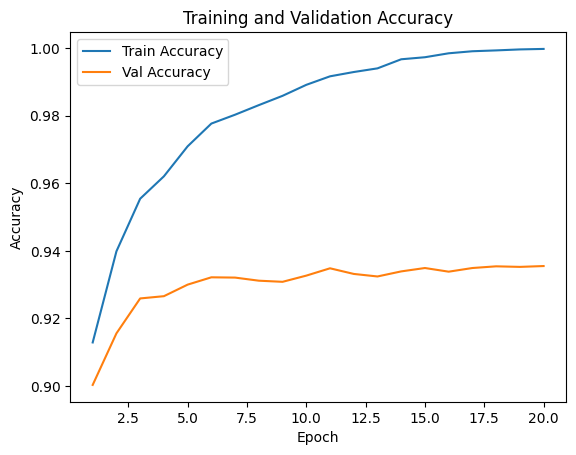

Best validation accuracy: 0.9355 at epoch 20
Test Accuracy for the best epoch with 64 hidden units: 0.8565
Epoch 1/20, Training Accuracy: 0.9234, Validation Accuracy: 0.9070
Epoch 2/20, Training Accuracy: 0.9518, Validation Accuracy: 0.9289
Epoch 3/20, Training Accuracy: 0.9672, Validation Accuracy: 0.9365
Epoch 4/20, Training Accuracy: 0.9764, Validation Accuracy: 0.9393
Epoch 5/20, Training Accuracy: 0.9747, Validation Accuracy: 0.9361
Epoch 6/20, Training Accuracy: 0.9881, Validation Accuracy: 0.9453
Epoch 7/20, Training Accuracy: 0.9933, Validation Accuracy: 0.9466
Epoch 8/20, Training Accuracy: 0.9955, Validation Accuracy: 0.9477
Epoch 9/20, Training Accuracy: 0.9976, Validation Accuracy: 0.9493
Epoch 10/20, Training Accuracy: 0.9979, Validation Accuracy: 0.9490
Epoch 11/20, Training Accuracy: 0.9990, Validation Accuracy: 0.9494
Epoch 12/20, Training Accuracy: 0.9993, Validation Accuracy: 0.9497
Epoch 13/20, Training Accuracy: 0.9994, Validation Accuracy: 0.9501
Epoch 14/20, Train

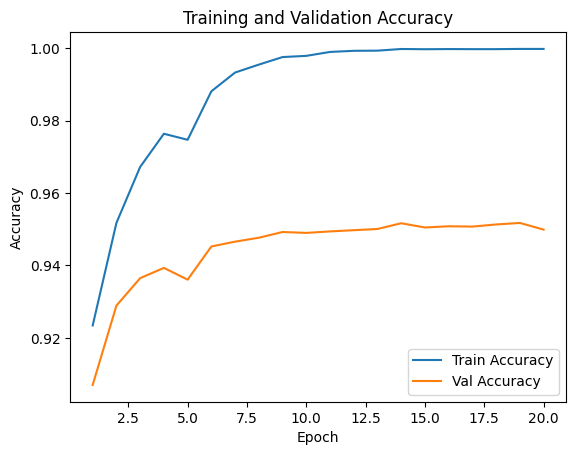

Best validation accuracy: 0.9517 at epoch 19
Test Accuracy for the best epoch with 128 hidden units: 0.8817
Epoch 1/20, Training Accuracy: 0.9275, Validation Accuracy: 0.9133
Epoch 2/20, Training Accuracy: 0.9565, Validation Accuracy: 0.9322
Epoch 3/20, Training Accuracy: 0.9739, Validation Accuracy: 0.9410
Epoch 4/20, Training Accuracy: 0.9820, Validation Accuracy: 0.9473
Epoch 5/20, Training Accuracy: 0.9859, Validation Accuracy: 0.9436
Epoch 6/20, Training Accuracy: 0.9941, Validation Accuracy: 0.9487
Epoch 7/20, Training Accuracy: 0.9926, Validation Accuracy: 0.9457
Epoch 8/20, Training Accuracy: 0.9970, Validation Accuracy: 0.9506
Epoch 9/20, Training Accuracy: 0.9984, Validation Accuracy: 0.9522
Epoch 10/20, Training Accuracy: 0.9993, Validation Accuracy: 0.9526
Epoch 11/20, Training Accuracy: 0.9995, Validation Accuracy: 0.9521
Epoch 12/20, Training Accuracy: 0.9995, Validation Accuracy: 0.9530
Epoch 13/20, Training Accuracy: 0.9998, Validation Accuracy: 0.9531
Epoch 14/20, Trai

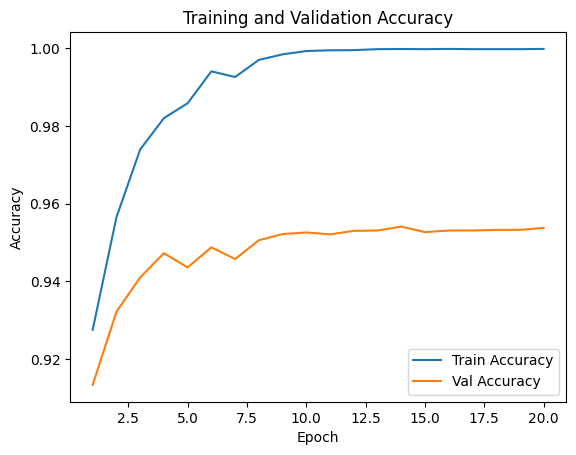

Best validation accuracy: 0.9541 at epoch 14
Test Accuracy for the best epoch with 256 hidden units: 0.8922


In [14]:
for num_hidden_units in [32,64,128,256]:
  mlp_one_hidden = MLP(input_size=784, num_hidden_layers=1, hidden_size=num_hidden_units, output_size=10, activation="relu")

  if num_hidden_units <128:
     # Run gradient check with a subset of the data before training
    X_small = X_train[:10]
    y_small = y_train[:10]
    for i in range(mlp_one_hidden.num_hidden_layers + 1):
        mlp_one_hidden.gradient_check_full_layer(X_small, y_small, layer_idx=i)

  mlp_one_hidden.fit(X_train, y_train, X_valid, y_valid, lr=0.1, epochs=20, batch_size=64, optimizer="sgd")

  best_weights = mlp_one_hidden.weights
  best_biases = mlp_one_hidden.biases

  test_preds = mlp_one_hidden.predict(X_test)
  test_acc = mlp_one_hidden.evaluate_acc(y_test, test_preds)
  print(f"Test Accuracy for the best epoch with {num_hidden_units} hidden units: {test_acc:.4f}")


test acuracies for mlp with **one hidden** layer and **ReLU activation**, batch size 64 and 20 epochs: \\
32:  ***82.75%*** \\
64:  ***86.05%*** \\
128: ***88.12%*** \\
256: ***89.12%***

Epoch 1/20, Training Accuracy: 0.8911, Validation Accuracy: 0.8828
Epoch 2/20, Training Accuracy: 0.9138, Validation Accuracy: 0.9037
Epoch 3/20, Training Accuracy: 0.9212, Validation Accuracy: 0.9068
Epoch 4/20, Training Accuracy: 0.9257, Validation Accuracy: 0.9104
Epoch 5/20, Training Accuracy: 0.9260, Validation Accuracy: 0.9094
Epoch 6/20, Training Accuracy: 0.9295, Validation Accuracy: 0.9132
Epoch 7/20, Training Accuracy: 0.9380, Validation Accuracy: 0.9195
Epoch 8/20, Training Accuracy: 0.9373, Validation Accuracy: 0.9170
Epoch 9/20, Training Accuracy: 0.9327, Validation Accuracy: 0.9126
Epoch 10/20, Training Accuracy: 0.9406, Validation Accuracy: 0.9214
Epoch 11/20, Training Accuracy: 0.9416, Validation Accuracy: 0.9197
Epoch 12/20, Training Accuracy: 0.9388, Validation Accuracy: 0.9205
Epoch 13/20, Training Accuracy: 0.9396, Validation Accuracy: 0.9180
Epoch 14/20, Training Accuracy: 0.9384, Validation Accuracy: 0.9177
Epoch 15/20, Training Accuracy: 0.9434, Validation Accura

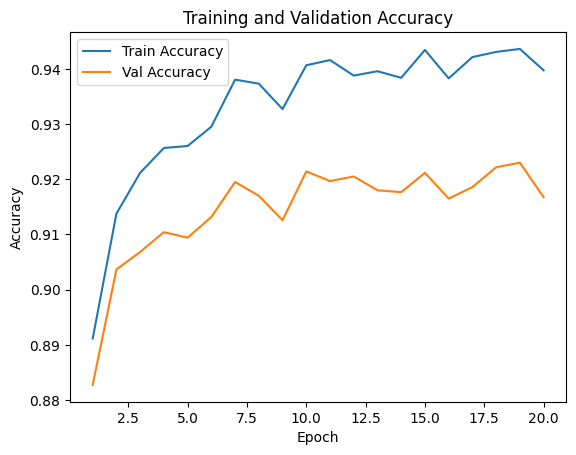

Best validation accuracy: 0.9230 at epoch 19
Test Accuracy for the best epoch with 32 hidden units: 0.8288
Epoch 1/20, Training Accuracy: 0.9103, Validation Accuracy: 0.9037
Epoch 2/20, Training Accuracy: 0.9306, Validation Accuracy: 0.9182
Epoch 3/20, Training Accuracy: 0.9423, Validation Accuracy: 0.9282
Epoch 4/20, Training Accuracy: 0.9490, Validation Accuracy: 0.9302
Epoch 5/20, Training Accuracy: 0.9547, Validation Accuracy: 0.9355
Epoch 6/20, Training Accuracy: 0.9592, Validation Accuracy: 0.9357
Epoch 7/20, Training Accuracy: 0.9612, Validation Accuracy: 0.9370
Epoch 8/20, Training Accuracy: 0.9619, Validation Accuracy: 0.9353
Epoch 9/20, Training Accuracy: 0.9642, Validation Accuracy: 0.9405
Epoch 10/20, Training Accuracy: 0.9621, Validation Accuracy: 0.9341
Epoch 11/20, Training Accuracy: 0.9662, Validation Accuracy: 0.9379
Epoch 12/20, Training Accuracy: 0.9686, Validation Accuracy: 0.9393
Epoch 13/20, Training Accuracy: 0.9674, Validation Accuracy: 0.9376
Epoch 14/20, Train

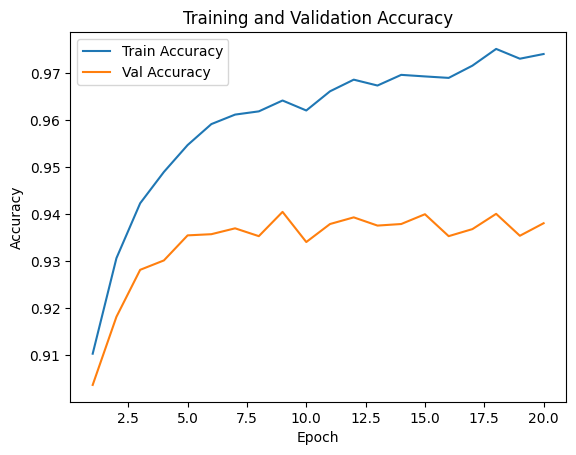

Best validation accuracy: 0.9405 at epoch 9
Test Accuracy for the best epoch with 64 hidden units: 0.8665
Epoch 1/20, Training Accuracy: 0.9157, Validation Accuracy: 0.9028
Epoch 2/20, Training Accuracy: 0.9416, Validation Accuracy: 0.9283
Epoch 3/20, Training Accuracy: 0.9546, Validation Accuracy: 0.9363
Epoch 4/20, Training Accuracy: 0.9639, Validation Accuracy: 0.9410
Epoch 5/20, Training Accuracy: 0.9699, Validation Accuracy: 0.9437
Epoch 6/20, Training Accuracy: 0.9717, Validation Accuracy: 0.9452
Epoch 7/20, Training Accuracy: 0.9776, Validation Accuracy: 0.9477
Epoch 8/20, Training Accuracy: 0.9775, Validation Accuracy: 0.9480
Epoch 9/20, Training Accuracy: 0.9814, Validation Accuracy: 0.9491
Epoch 10/20, Training Accuracy: 0.9828, Validation Accuracy: 0.9483
Epoch 11/20, Training Accuracy: 0.9846, Validation Accuracy: 0.9503
Epoch 12/20, Training Accuracy: 0.9833, Validation Accuracy: 0.9507
Epoch 13/20, Training Accuracy: 0.9879, Validation Accuracy: 0.9507
Epoch 14/20, Traini

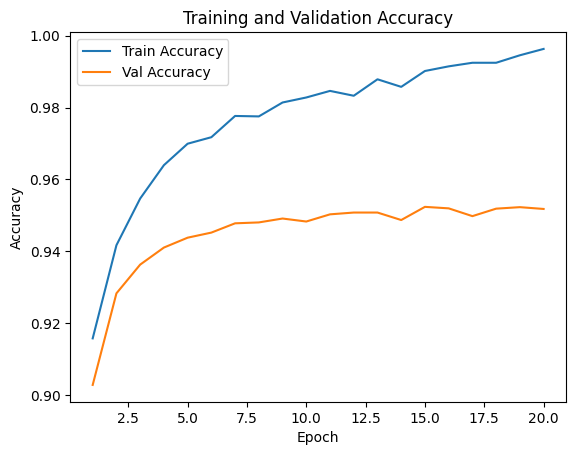

Best validation accuracy: 0.9523 at epoch 15
Test Accuracy for the best epoch with 128 hidden units: 0.8931
Epoch 1/20, Training Accuracy: 0.9230, Validation Accuracy: 0.9138
Epoch 2/20, Training Accuracy: 0.9474, Validation Accuracy: 0.9357
Epoch 3/20, Training Accuracy: 0.9585, Validation Accuracy: 0.9413
Epoch 4/20, Training Accuracy: 0.9695, Validation Accuracy: 0.9486
Epoch 5/20, Training Accuracy: 0.9764, Validation Accuracy: 0.9501
Epoch 6/20, Training Accuracy: 0.9812, Validation Accuracy: 0.9528
Epoch 7/20, Training Accuracy: 0.9838, Validation Accuracy: 0.9524
Epoch 8/20, Training Accuracy: 0.9875, Validation Accuracy: 0.9547
Epoch 9/20, Training Accuracy: 0.9876, Validation Accuracy: 0.9523
Epoch 10/20, Training Accuracy: 0.9899, Validation Accuracy: 0.9552
Epoch 11/20, Training Accuracy: 0.9902, Validation Accuracy: 0.9557
Epoch 12/20, Training Accuracy: 0.9947, Validation Accuracy: 0.9555
Epoch 13/20, Training Accuracy: 0.9960, Validation Accuracy: 0.9570
Epoch 14/20, Trai

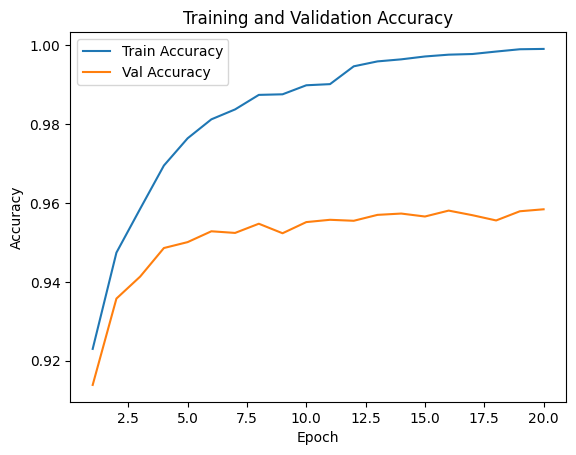

Best validation accuracy: 0.9584 at epoch 20
Test Accuracy for the best epoch with 256 hidden units: 0.9078


In [ ]:
#extra pca experiment
for num_hidden_units in [32,64,128,256]:
  mlp_one_hidden = MLP(input_size=100, num_hidden_layers=1, hidden_size=num_hidden_units, output_size=10, activation="relu")
  mlp_one_hidden.fit(X_train_reduced, y_train, X_val_reduced, y_valid, lr=0.1, epochs=20, batch_size=64, optimizer="sgd")

  best_weights = mlp_one_hidden.weights
  best_biases = mlp_one_hidden.biases

  test_preds = mlp_one_hidden.predict(X_test_reduced)
  test_acc = mlp_one_hidden.evaluate_acc(y_test, test_preds)
  print(f"Test Accuracy for the best epoch with {num_hidden_units} hidden units: {test_acc:.4f}")

###3.1.3: MLP with 2 hidden layers having ReLU activations

Layer 0 weights shape: (784, 32)
Layer 1 weights shape: (32, 32)
Layer 2 weights shape: (32, 10)
Relative error for layer 0: 1.2166472720e-07
Gradient check failed for layer 0.
Layer 0 weights shape: (784, 32)
Layer 1 weights shape: (32, 32)
Layer 2 weights shape: (32, 10)
Relative error for layer 1: 1.7154829741e-08
Gradient check passed for layer 1.
Layer 0 weights shape: (784, 32)
Layer 1 weights shape: (32, 32)
Layer 2 weights shape: (32, 10)
Relative error for layer 2: 8.0077315580e-09
Gradient check passed for layer 2.
Epoch 1/20, Training Accuracy: 0.8434, Validation Accuracy: 0.8367
Epoch 2/20, Training Accuracy: 0.9061, Validation Accuracy: 0.8928
Epoch 3/20, Training Accuracy: 0.9238, Validation Accuracy: 0.9055
Epoch 4/20, Training Accuracy: 0.9308, Validation Accuracy: 0.9039
Epoch 5/20, Training Accuracy: 0.9376, Validation Accuracy: 0.9113
Epoch 6/20, Training Accuracy: 0.9507, Validation Accuracy: 0.9158
Epoch 7/20, Training Accuracy: 0.9542, Validation Accuracy: 0.9187


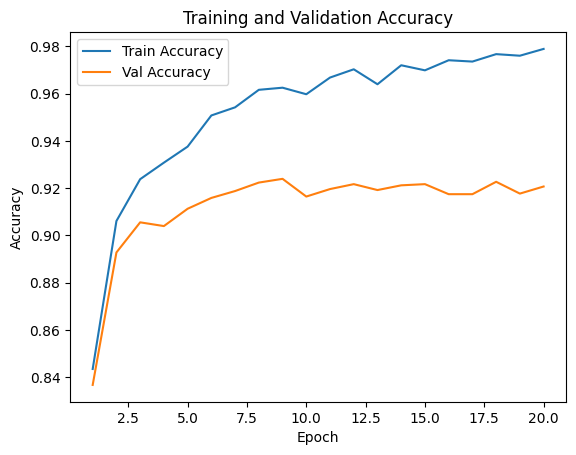

Best validation accuracy: 0.9239 at epoch 9
Test Accuracy for the best epoch with 32 hidden units: 0.8443
Layer 0 weights shape: (784, 64)
Layer 1 weights shape: (64, 64)
Layer 2 weights shape: (64, 10)
Relative error for layer 0: 7.7784927636e-08
Gradient check passed for layer 0.
Layer 0 weights shape: (784, 64)
Layer 1 weights shape: (64, 64)
Layer 2 weights shape: (64, 10)
Relative error for layer 1: 1.5745533992e-08
Gradient check passed for layer 1.
Layer 0 weights shape: (784, 64)
Layer 1 weights shape: (64, 64)
Layer 2 weights shape: (64, 10)
Relative error for layer 2: 6.0325107098e-09
Gradient check passed for layer 2.
Epoch 1/20, Training Accuracy: 0.8793, Validation Accuracy: 0.8672
Epoch 2/20, Training Accuracy: 0.9264, Validation Accuracy: 0.9097
Epoch 3/20, Training Accuracy: 0.9465, Validation Accuracy: 0.9200
Epoch 4/20, Training Accuracy: 0.9615, Validation Accuracy: 0.9295
Epoch 5/20, Training Accuracy: 0.9690, Validation Accuracy: 0.9343
Epoch 6/20, Training Accurac

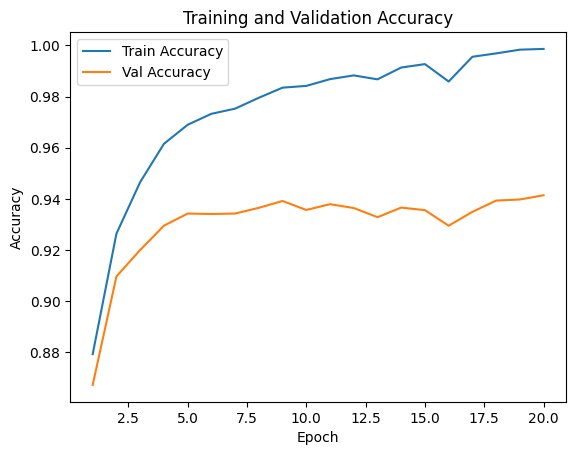

Best validation accuracy: 0.9414 at epoch 20
Test Accuracy for the best epoch with 64 hidden units: 0.8673
Epoch 1/20, Training Accuracy: 0.9018, Validation Accuracy: 0.8895
Epoch 2/20, Training Accuracy: 0.9425, Validation Accuracy: 0.9233
Epoch 3/20, Training Accuracy: 0.9623, Validation Accuracy: 0.9306
Epoch 4/20, Training Accuracy: 0.9723, Validation Accuracy: 0.9369
Epoch 5/20, Training Accuracy: 0.9785, Validation Accuracy: 0.9382
Epoch 6/20, Training Accuracy: 0.9833, Validation Accuracy: 0.9402
Epoch 7/20, Training Accuracy: 0.9857, Validation Accuracy: 0.9419
Epoch 8/20, Training Accuracy: 0.9889, Validation Accuracy: 0.9423
Epoch 9/20, Training Accuracy: 0.9926, Validation Accuracy: 0.9450
Epoch 10/20, Training Accuracy: 0.9970, Validation Accuracy: 0.9481
Epoch 11/20, Training Accuracy: 0.9981, Validation Accuracy: 0.9483
Epoch 12/20, Training Accuracy: 0.9987, Validation Accuracy: 0.9474
Epoch 13/20, Training Accuracy: 0.9996, Validation Accuracy: 0.9517
Epoch 14/20, Train

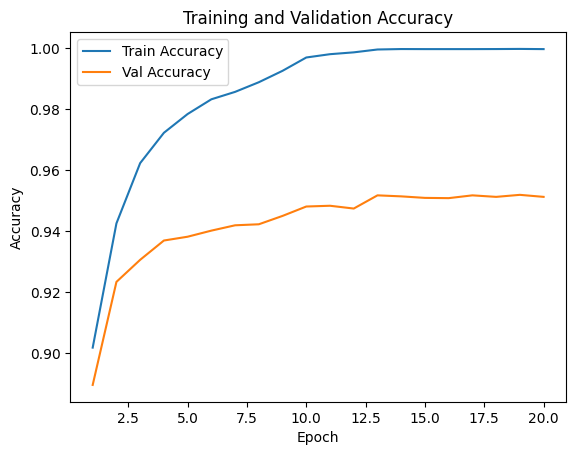

Best validation accuracy: 0.9519 at epoch 19
Test Accuracy for the best epoch with 128 hidden units: 0.8825
Epoch 1/20, Training Accuracy: 0.9132, Validation Accuracy: 0.9027
Epoch 2/20, Training Accuracy: 0.9440, Validation Accuracy: 0.9192
Epoch 3/20, Training Accuracy: 0.9709, Validation Accuracy: 0.9421
Epoch 4/20, Training Accuracy: 0.9712, Validation Accuracy: 0.9373
Epoch 5/20, Training Accuracy: 0.9851, Validation Accuracy: 0.9434
Epoch 6/20, Training Accuracy: 0.9911, Validation Accuracy: 0.9490
Epoch 7/20, Training Accuracy: 0.9894, Validation Accuracy: 0.9447
Epoch 8/20, Training Accuracy: 0.9943, Validation Accuracy: 0.9501
Epoch 9/20, Training Accuracy: 0.9933, Validation Accuracy: 0.9477
Epoch 10/20, Training Accuracy: 0.9986, Validation Accuracy: 0.9516
Epoch 11/20, Training Accuracy: 0.9995, Validation Accuracy: 0.9514
Epoch 12/20, Training Accuracy: 0.9995, Validation Accuracy: 0.9541
Epoch 13/20, Training Accuracy: 0.9998, Validation Accuracy: 0.9547
Epoch 14/20, Trai

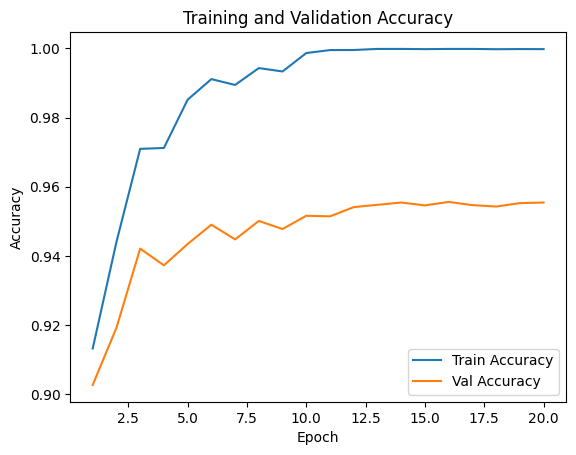

Best validation accuracy: 0.9556 at epoch 16
Test Accuracy for the best epoch with 256 hidden units: 0.8923


In [ ]:
for num_hidden_units in [32,64,128,256]:
  mlp_two_hidden = MLP(input_size=784, num_hidden_layers=2, hidden_size=num_hidden_units, output_size=10, activation="relu")


  if num_hidden_units <128:
    # Run gradient check before training
    X_small = X_train[:10]
    y_small = y_train[:10]
    for i in range(mlp_two_hidden.num_hidden_layers + 1):
        mlp_two_hidden.gradient_check_full_layer(X_small, y_small, layer_idx=i)

  mlp_two_hidden.fit(X_train, y_train, X_valid, y_valid, lr=0.1, epochs=20, batch_size=64, optimizer="sgd")

  best_weights = mlp_two_hidden.weights
  best_biases = mlp_two_hidden.biases

  test_preds = mlp_two_hidden.predict(X_test)
  test_acc = mlp_two_hidden.evaluate_acc(y_test, test_preds)
  print(f"Test Accuracy for the best epoch with {num_hidden_units} hidden units: {test_acc:.4f}")

test acuracies for mlp with **two hidden** layer and **ReLU activation**, batch size 64 and 20 epochs: \\
32:  ***83.63%*** \\
64:  ***86.80%*** \\
128: ***88.58%*** \\
256: ***89.25%***

##3.2: MLP with 2 hidden layers having sigmoid and Leaky-ReLU activations.

Epoch 1/20, Training Accuracy: 0.9202, Validation Accuracy: 0.9058
Epoch 2/20, Training Accuracy: 0.9337, Validation Accuracy: 0.9082
Epoch 3/20, Training Accuracy: 0.9692, Validation Accuracy: 0.9387
Epoch 4/20, Training Accuracy: 0.9784, Validation Accuracy: 0.9403
Epoch 5/20, Training Accuracy: 0.9821, Validation Accuracy: 0.9452
Epoch 6/20, Training Accuracy: 0.9892, Validation Accuracy: 0.9476
Epoch 7/20, Training Accuracy: 0.9937, Validation Accuracy: 0.9496
Epoch 8/20, Training Accuracy: 0.9942, Validation Accuracy: 0.9493
Epoch 9/20, Training Accuracy: 0.9981, Validation Accuracy: 0.9531
Epoch 10/20, Training Accuracy: 0.9989, Validation Accuracy: 0.9547
Epoch 11/20, Training Accuracy: 0.9998, Validation Accuracy: 0.9569
Epoch 12/20, Training Accuracy: 0.9998, Validation Accuracy: 0.9573
Epoch 13/20, Training Accuracy: 0.9998, Validation Accuracy: 0.9571
Epoch 14/20, Training Accuracy: 0.9998, Validation Accuracy: 0.9579
Epoch 15/20, Training Accuracy: 0.9998, Validation Accura

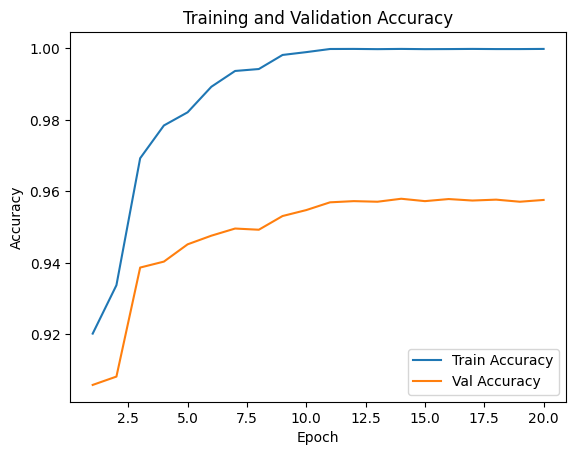

Best validation accuracy: 0.9579 at epoch 14
Test Accuracy for the best epoch using the relu as activation: 0.8950
Epoch 1/20, Training Accuracy: 0.2824, Validation Accuracy: 0.2795
Epoch 2/20, Training Accuracy: 0.6732, Validation Accuracy: 0.6723
Epoch 3/20, Training Accuracy: 0.7574, Validation Accuracy: 0.7528
Epoch 4/20, Training Accuracy: 0.7875, Validation Accuracy: 0.7819
Epoch 5/20, Training Accuracy: 0.8041, Validation Accuracy: 0.7960
Epoch 6/20, Training Accuracy: 0.8212, Validation Accuracy: 0.8145
Epoch 7/20, Training Accuracy: 0.8328, Validation Accuracy: 0.8257
Epoch 8/20, Training Accuracy: 0.8404, Validation Accuracy: 0.8311
Epoch 9/20, Training Accuracy: 0.8471, Validation Accuracy: 0.8347
Epoch 10/20, Training Accuracy: 0.8505, Validation Accuracy: 0.8368
Epoch 11/20, Training Accuracy: 0.8539, Validation Accuracy: 0.8414
Epoch 12/20, Training Accuracy: 0.8603, Validation Accuracy: 0.8468
Epoch 13/20, Training Accuracy: 0.8614, Validation Accuracy: 0.8485
Epoch 14/2

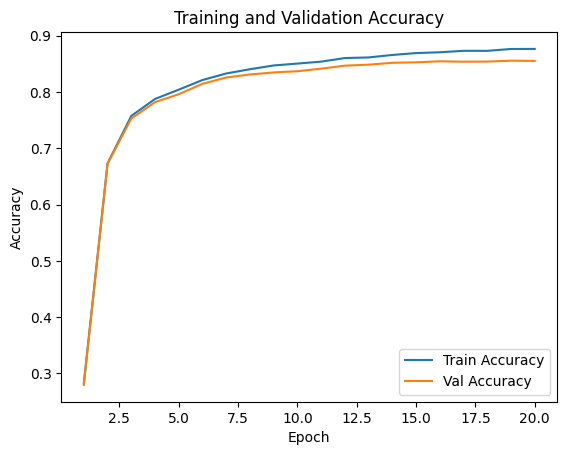

Best validation accuracy: 0.8556 at epoch 19
Test Accuracy for the best epoch using the sigmoid as activation: 0.7386
Epoch 1/20, Training Accuracy: 0.9124, Validation Accuracy: 0.9021
Epoch 2/20, Training Accuracy: 0.9520, Validation Accuracy: 0.9273
Epoch 3/20, Training Accuracy: 0.9677, Validation Accuracy: 0.9381
Epoch 4/20, Training Accuracy: 0.9785, Validation Accuracy: 0.9467
Epoch 5/20, Training Accuracy: 0.9850, Validation Accuracy: 0.9469
Epoch 6/20, Training Accuracy: 0.9916, Validation Accuracy: 0.9478
Epoch 7/20, Training Accuracy: 0.9903, Validation Accuracy: 0.9431
Epoch 8/20, Training Accuracy: 0.9958, Validation Accuracy: 0.9516
Epoch 9/20, Training Accuracy: 0.9982, Validation Accuracy: 0.9517
Epoch 10/20, Training Accuracy: 0.9983, Validation Accuracy: 0.9484
Epoch 11/20, Training Accuracy: 0.9975, Validation Accuracy: 0.9529
Epoch 12/20, Training Accuracy: 0.9886, Validation Accuracy: 0.9411
Epoch 13/20, Training Accuracy: 0.9992, Validation Accuracy: 0.9523
Epoch 1

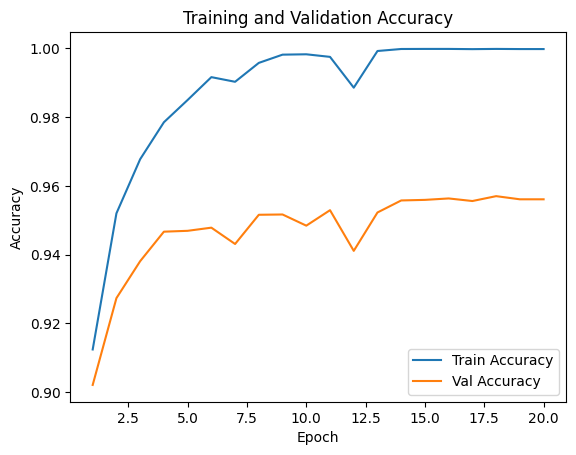

Best validation accuracy: 0.9570 at epoch 18
Test Accuracy for the best epoch using the leaky_relu as activation: 0.8942


In [ ]:
for act in ["relu", "sigmoid","leaky_relu"]:
    mlp_two_hidden = MLP(input_size=784, num_hidden_layers=2, hidden_size=256, output_size=10, activation=act)

    # Run gradient check before training
    X_small = X_train[:3]
    y_small = y_train[:3]

    mlp_two_hidden.fit(X_train, y_train, X_valid, y_valid, lr=0.1, epochs=20, batch_size=64, optimizer="sgd")

    best_weights = mlp_two_hidden.weights
    best_biases = mlp_two_hidden.biases

    test_preds = mlp_two_hidden.predict(X_test)
    test_acc = mlp_two_hidden.evaluate_acc(y_test, test_preds)
    print(f"Test Accuracy for the best epoch using the {act} as activation: {test_acc:.4f}")

test acuracies for mlp with **two hidden** layer and **256 hidden units**, batch size 64 and 20 epochs: \\
ReLU:  ***89.54%*** \\
Sigmoid: ***71.53%*** \\
Leaky ReLU: ***89.56%***

Epoch 1/20, Training Accuracy: 0.8342, Validation Accuracy: 0.8298
Epoch 2/20, Training Accuracy: 0.8996, Validation Accuracy: 0.8898
Epoch 3/20, Training Accuracy: 0.9189, Validation Accuracy: 0.9099
Epoch 4/20, Training Accuracy: 0.9246, Validation Accuracy: 0.9130
Epoch 5/20, Training Accuracy: 0.9344, Validation Accuracy: 0.9197
Epoch 6/20, Training Accuracy: 0.9363, Validation Accuracy: 0.9228
Epoch 7/20, Training Accuracy: 0.9421, Validation Accuracy: 0.9261
Epoch 8/20, Training Accuracy: 0.9398, Validation Accuracy: 0.9216
Epoch 9/20, Training Accuracy: 0.9450, Validation Accuracy: 0.9235
Epoch 10/20, Training Accuracy: 0.9433, Validation Accuracy: 0.9283
Epoch 11/20, Training Accuracy: 0.9443, Validation Accuracy: 0.9240
Epoch 12/20, Training Accuracy: 0.9518, Validation Accuracy: 0.9278
Epoch 13/20, Training Accuracy: 0.9525, Validation Accuracy: 0.9317
Epoch 14/20, Training Accuracy: 0.9522, Validation Accuracy: 0.9280
Epoch 15/20, Training Accuracy: 0.9539, Validation Accura

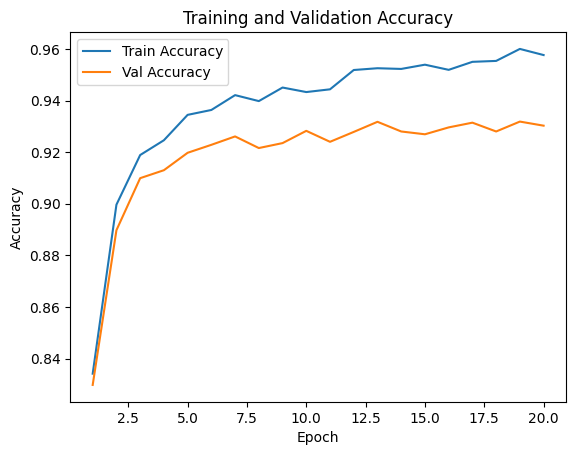

Best validation accuracy: 0.9318 at epoch 19
Test Accuracy for the best epoch with 32 hidden units: 0.8471
Epoch 1/20, Training Accuracy: 0.8748, Validation Accuracy: 0.8679
Epoch 2/20, Training Accuracy: 0.9250, Validation Accuracy: 0.9168
Epoch 3/20, Training Accuracy: 0.9398, Validation Accuracy: 0.9254
Epoch 4/20, Training Accuracy: 0.9481, Validation Accuracy: 0.9313
Epoch 5/20, Training Accuracy: 0.9581, Validation Accuracy: 0.9399
Epoch 6/20, Training Accuracy: 0.9564, Validation Accuracy: 0.9366
Epoch 7/20, Training Accuracy: 0.9627, Validation Accuracy: 0.9427
Epoch 8/20, Training Accuracy: 0.9686, Validation Accuracy: 0.9447
Epoch 9/20, Training Accuracy: 0.9692, Validation Accuracy: 0.9409
Epoch 10/20, Training Accuracy: 0.9736, Validation Accuracy: 0.9455
Epoch 11/20, Training Accuracy: 0.9736, Validation Accuracy: 0.9428
Epoch 12/20, Training Accuracy: 0.9743, Validation Accuracy: 0.9443
Epoch 13/20, Training Accuracy: 0.9764, Validation Accuracy: 0.9454
Epoch 14/20, Train

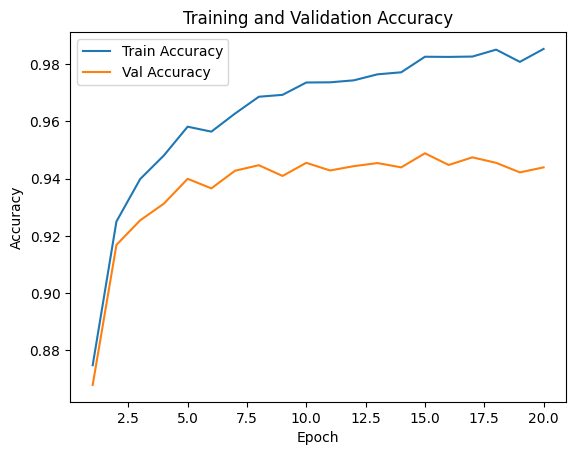

Best validation accuracy: 0.9488 at epoch 15
Test Accuracy for the best epoch with 64 hidden units: 0.8847
Epoch 1/20, Training Accuracy: 0.9000, Validation Accuracy: 0.8966
Epoch 2/20, Training Accuracy: 0.9359, Validation Accuracy: 0.9229
Epoch 3/20, Training Accuracy: 0.9570, Validation Accuracy: 0.9377
Epoch 4/20, Training Accuracy: 0.9630, Validation Accuracy: 0.9439
Epoch 5/20, Training Accuracy: 0.9690, Validation Accuracy: 0.9450
Epoch 6/20, Training Accuracy: 0.9744, Validation Accuracy: 0.9487
Epoch 7/20, Training Accuracy: 0.9742, Validation Accuracy: 0.9498
Epoch 8/20, Training Accuracy: 0.9794, Validation Accuracy: 0.9487
Epoch 9/20, Training Accuracy: 0.9810, Validation Accuracy: 0.9507
Epoch 10/20, Training Accuracy: 0.9840, Validation Accuracy: 0.9504
Epoch 11/20, Training Accuracy: 0.9864, Validation Accuracy: 0.9510
Epoch 12/20, Training Accuracy: 0.9876, Validation Accuracy: 0.9514
Epoch 13/20, Training Accuracy: 0.9916, Validation Accuracy: 0.9561
Epoch 14/20, Train

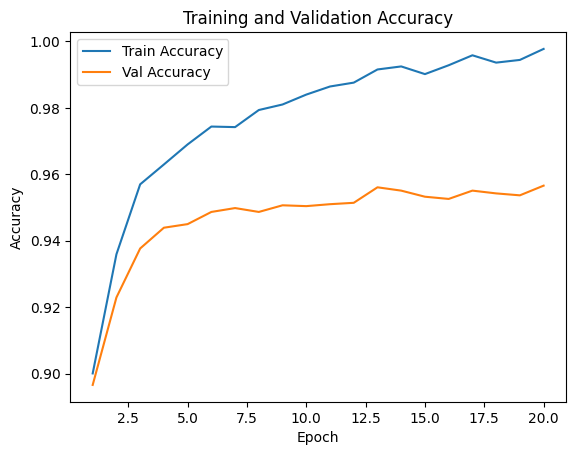

Best validation accuracy: 0.9566 at epoch 20
Test Accuracy for the best epoch with 128 hidden units: 0.8993
Epoch 1/20, Training Accuracy: 0.9069, Validation Accuracy: 0.9023
Epoch 2/20, Training Accuracy: 0.9477, Validation Accuracy: 0.9326
Epoch 3/20, Training Accuracy: 0.9627, Validation Accuracy: 0.9435
Epoch 4/20, Training Accuracy: 0.9709, Validation Accuracy: 0.9511
Epoch 5/20, Training Accuracy: 0.9722, Validation Accuracy: 0.9467
Epoch 6/20, Training Accuracy: 0.9812, Validation Accuracy: 0.9530
Epoch 7/20, Training Accuracy: 0.9835, Validation Accuracy: 0.9526
Epoch 8/20, Training Accuracy: 0.9865, Validation Accuracy: 0.9552
Epoch 9/20, Training Accuracy: 0.9884, Validation Accuracy: 0.9537
Epoch 10/20, Training Accuracy: 0.9908, Validation Accuracy: 0.9549
Epoch 11/20, Training Accuracy: 0.9929, Validation Accuracy: 0.9567
Epoch 12/20, Training Accuracy: 0.9935, Validation Accuracy: 0.9571
Epoch 13/20, Training Accuracy: 0.9938, Validation Accuracy: 0.9566
Epoch 14/20, Trai

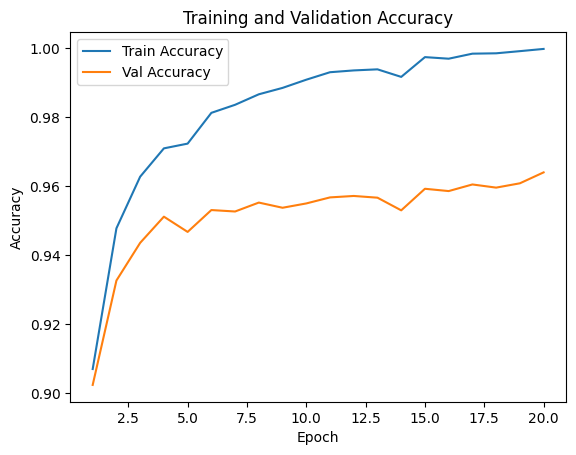

Best validation accuracy: 0.9639 at epoch 20
Test Accuracy for the best epoch with 256 hidden units: 0.9088


In [ ]:
for num_hidden_units in [32,64,128,256]:
  mlp_two_hidden = MLP(input_size=100, num_hidden_layers=2, hidden_size=num_hidden_units, output_size=10, activation="relu")
  mlp_two_hidden.fit(X_train_reduced, y_train, X_val_reduced, y_valid, lr=0.1, epochs=20, batch_size=64, optimizer="sgd")

  best_weights = mlp_two_hidden.weights
  best_biases = mlp_two_hidden.biases

  test_preds = mlp_two_hidden.predict(X_test_reduced)
  test_acc = mlp_two_hidden.evaluate_acc(y_test, test_preds)
  print(f"Test Accuracy for the best epoch with {num_hidden_units} hidden units: {test_acc:.4f}")

##3.3: MLP with two hidden layers with L2 regularization

Lambda: 0
Epoch 1/20, Training Accuracy: 0.9159, Validation Accuracy: 0.9012
Epoch 2/20, Training Accuracy: 0.9526, Validation Accuracy: 0.9314
Epoch 3/20, Training Accuracy: 0.9675, Validation Accuracy: 0.9363
Epoch 4/20, Training Accuracy: 0.9802, Validation Accuracy: 0.9430
Epoch 5/20, Training Accuracy: 0.9808, Validation Accuracy: 0.9430
Epoch 6/20, Training Accuracy: 0.9892, Validation Accuracy: 0.9455
Epoch 7/20, Training Accuracy: 0.9925, Validation Accuracy: 0.9492
Epoch 8/20, Training Accuracy: 0.9941, Validation Accuracy: 0.9480
Epoch 9/20, Training Accuracy: 0.9976, Validation Accuracy: 0.9532
Epoch 10/20, Training Accuracy: 0.9953, Validation Accuracy: 0.9495
Epoch 11/20, Training Accuracy: 0.9971, Validation Accuracy: 0.9527
Epoch 12/20, Training Accuracy: 0.9994, Validation Accuracy: 0.9548
Epoch 13/20, Training Accuracy: 0.9998, Validation Accuracy: 0.9546
Epoch 14/20, Training Accuracy: 0.9997, Validation Accuracy: 0.9553
Epoch 15/20, Training Accuracy: 0.9998, Validat

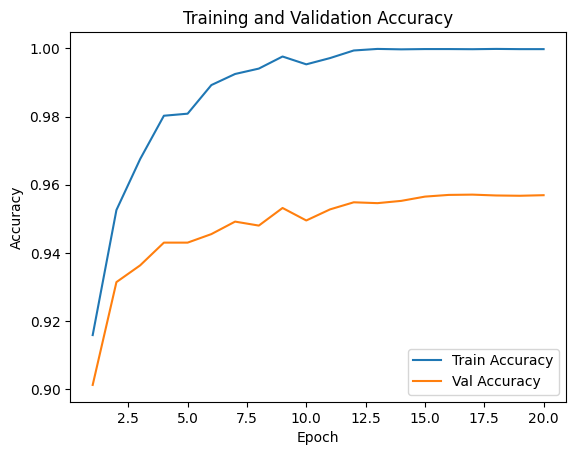

Best validation accuracy: 0.9571 at epoch 17
Test Accuracy for the best epoch with λ = 0: 0.8924
Lambda: 0.0001
Epoch 1/20, Training Accuracy: 0.9157, Validation Accuracy: 0.9043
Epoch 2/20, Training Accuracy: 0.9411, Validation Accuracy: 0.9188
Epoch 3/20, Training Accuracy: 0.9704, Validation Accuracy: 0.9411
Epoch 4/20, Training Accuracy: 0.9768, Validation Accuracy: 0.9382
Epoch 5/20, Training Accuracy: 0.9860, Validation Accuracy: 0.9462
Epoch 6/20, Training Accuracy: 0.9895, Validation Accuracy: 0.9450
Epoch 7/20, Training Accuracy: 0.9904, Validation Accuracy: 0.9454
Epoch 8/20, Training Accuracy: 0.9972, Validation Accuracy: 0.9523
Epoch 9/20, Training Accuracy: 0.9981, Validation Accuracy: 0.9487
Epoch 10/20, Training Accuracy: 0.9990, Validation Accuracy: 0.9524
Epoch 11/20, Training Accuracy: 0.9997, Validation Accuracy: 0.9555
Epoch 12/20, Training Accuracy: 0.9998, Validation Accuracy: 0.9545
Epoch 13/20, Training Accuracy: 0.9998, Validation Accuracy: 0.9532
Epoch 14/20, 

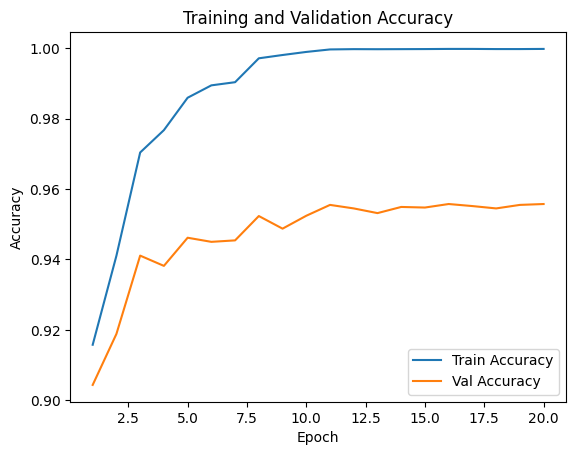

Best validation accuracy: 0.9557 at epoch 16
Test Accuracy for the best epoch with λ = 0.0001: 0.8962
Lambda: 0.001
Epoch 1/20, Training Accuracy: 0.9177, Validation Accuracy: 0.9040
Epoch 2/20, Training Accuracy: 0.9519, Validation Accuracy: 0.9298
Epoch 3/20, Training Accuracy: 0.9681, Validation Accuracy: 0.9379
Epoch 4/20, Training Accuracy: 0.9771, Validation Accuracy: 0.9419
Epoch 5/20, Training Accuracy: 0.9830, Validation Accuracy: 0.9469
Epoch 6/20, Training Accuracy: 0.9862, Validation Accuracy: 0.9459
Epoch 7/20, Training Accuracy: 0.9812, Validation Accuracy: 0.9387
Epoch 8/20, Training Accuracy: 0.9944, Validation Accuracy: 0.9498
Epoch 9/20, Training Accuracy: 0.9960, Validation Accuracy: 0.9517
Epoch 10/20, Training Accuracy: 0.9970, Validation Accuracy: 0.9506
Epoch 11/20, Training Accuracy: 0.9981, Validation Accuracy: 0.9527
Epoch 12/20, Training Accuracy: 0.9988, Validation Accuracy: 0.9530
Epoch 13/20, Training Accuracy: 0.9989, Validation Accuracy: 0.9517
Epoch 14/

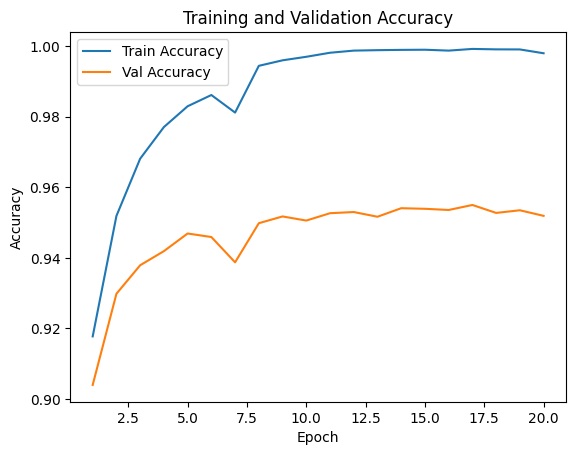

Best validation accuracy: 0.9550 at epoch 17
Test Accuracy for the best epoch with λ = 0.001: 0.8947
Lambda: 0.01
Epoch 1/20, Training Accuracy: 0.8958, Validation Accuracy: 0.8835
Epoch 2/20, Training Accuracy: 0.9318, Validation Accuracy: 0.9158
Epoch 3/20, Training Accuracy: 0.9406, Validation Accuracy: 0.9216
Epoch 4/20, Training Accuracy: 0.9476, Validation Accuracy: 0.9272
Epoch 5/20, Training Accuracy: 0.9506, Validation Accuracy: 0.9307
Epoch 6/20, Training Accuracy: 0.9481, Validation Accuracy: 0.9301
Epoch 7/20, Training Accuracy: 0.9564, Validation Accuracy: 0.9355
Epoch 8/20, Training Accuracy: 0.9552, Validation Accuracy: 0.9328
Epoch 9/20, Training Accuracy: 0.9575, Validation Accuracy: 0.9345
Epoch 10/20, Training Accuracy: 0.9570, Validation Accuracy: 0.9347
Epoch 11/20, Training Accuracy: 0.9554, Validation Accuracy: 0.9343
Epoch 12/20, Training Accuracy: 0.9578, Validation Accuracy: 0.9378
Epoch 13/20, Training Accuracy: 0.9544, Validation Accuracy: 0.9337
Epoch 14/20

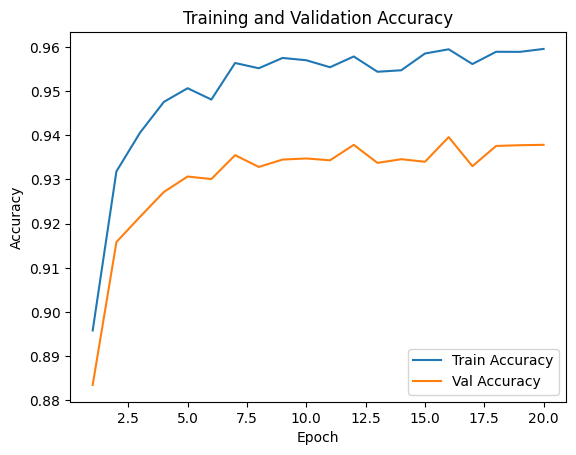

Best validation accuracy: 0.9396 at epoch 16
Test Accuracy for the best epoch with λ = 0.01: 0.8571
Lambda: 0.1
Epoch 1/20, Training Accuracy: 0.2210, Validation Accuracy: 0.2184
Epoch 2/20, Training Accuracy: 0.3489, Validation Accuracy: 0.3469
Epoch 3/20, Training Accuracy: 0.6533, Validation Accuracy: 0.6517
Epoch 4/20, Training Accuracy: 0.7243, Validation Accuracy: 0.7205
Epoch 5/20, Training Accuracy: 0.7624, Validation Accuracy: 0.7608
Epoch 6/20, Training Accuracy: 0.7607, Validation Accuracy: 0.7582
Epoch 7/20, Training Accuracy: 0.7799, Validation Accuracy: 0.7787
Epoch 8/20, Training Accuracy: 0.7859, Validation Accuracy: 0.7826
Epoch 9/20, Training Accuracy: 0.7773, Validation Accuracy: 0.7788
Epoch 10/20, Training Accuracy: 0.7638, Validation Accuracy: 0.7602
Epoch 11/20, Training Accuracy: 0.7680, Validation Accuracy: 0.7670
Epoch 12/20, Training Accuracy: 0.7785, Validation Accuracy: 0.7738
Epoch 13/20, Training Accuracy: 0.7862, Validation Accuracy: 0.7857
Epoch 14/20, 

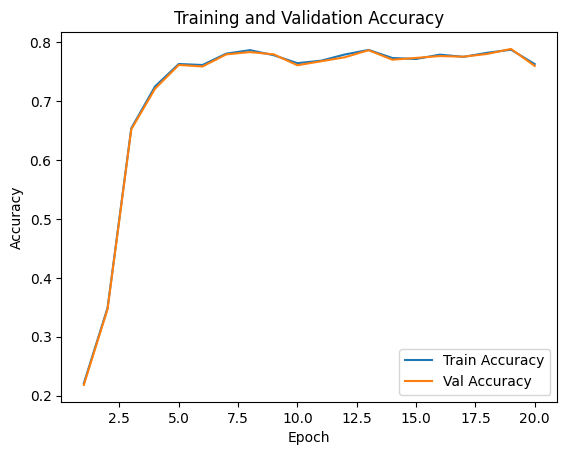

Best validation accuracy: 0.7879 at epoch 19
Test Accuracy for the best epoch with λ = 0.1: 0.6333
Lambda: 1
Epoch 1/20, Training Accuracy: 0.1001, Validation Accuracy: 0.0995
Epoch 2/20, Training Accuracy: 0.1009, Validation Accuracy: 0.0963
Epoch 3/20, Training Accuracy: 0.1000, Validation Accuracy: 0.1000
Epoch 4/20, Training Accuracy: 0.0999, Validation Accuracy: 0.1004
Epoch 5/20, Training Accuracy: 0.0998, Validation Accuracy: 0.1008
Epoch 6/20, Training Accuracy: 0.1000, Validation Accuracy: 0.1000
Epoch 7/20, Training Accuracy: 0.1002, Validation Accuracy: 0.0993
Epoch 8/20, Training Accuracy: 0.1007, Validation Accuracy: 0.0973
Epoch 9/20, Training Accuracy: 0.1009, Validation Accuracy: 0.0963
Epoch 10/20, Training Accuracy: 0.1002, Validation Accuracy: 0.0993
Epoch 11/20, Training Accuracy: 0.1007, Validation Accuracy: 0.0973
Epoch 12/20, Training Accuracy: 0.0999, Validation Accuracy: 0.1004
Epoch 13/20, Training Accuracy: 0.1001, Validation Accuracy: 0.0995
Epoch 14/20, Tra

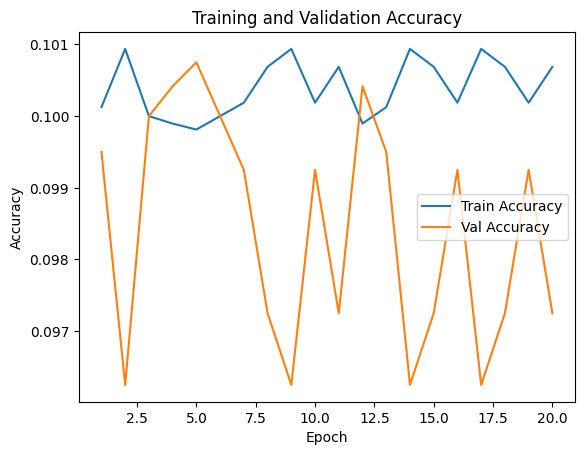

Best validation accuracy: 0.1008 at epoch 5
Test Accuracy for the best epoch with λ = 1: 0.1000


In [ ]:
for lam in [0, 0.0001, 0.001, 0.01, 0.1, 1]:
    mlp_two_hidden = MLP(input_size=784, num_hidden_layers=2, hidden_size=256, output_size=10, activation="relu", l2_lambda=lam)

    # Run gradient check before training
    X_small = X_train[:3]
    y_small = y_train[:3]

    print(f"Lambda: {lam}")

    #mlp_two_hidden.gradient_check_full_layer(X_small, y_small, layer_idx=0)

    mlp_two_hidden.fit(X_train, y_train, X_valid, y_valid, lr=0.1, epochs=20, batch_size=64, optimizer="sgd")
    best_weights = mlp_two_hidden.weights
    best_biases = mlp_two_hidden.biases

    test_preds = mlp_two_hidden.predict(X_test)
    test_acc = mlp_two_hidden.evaluate_acc(y_test, test_preds)
    print(f"Test Accuracy for the best epoch with λ = {lam}: {test_acc:.4f}")

test acuracies for mlp with **two hidden** layer and **256 hidden units**, batch size 64 and 20 epochs and ReLU: \\
λ=0.1 ***62.82%*** \\
λ=0.01 ***86.37%*** \\
λ=0.001 ***89.75%*** \\
λ=0.0001 ***89.50%***
λ=0   ***89.07%*** \\

Lambda: 0.001
Epoch 1/20, Training Accuracy: 0.9100, Validation Accuracy: 0.8983
Epoch 2/20, Training Accuracy: 0.9498, Validation Accuracy: 0.9278
Epoch 3/20, Training Accuracy: 0.9665, Validation Accuracy: 0.9373
Epoch 4/20, Training Accuracy: 0.9736, Validation Accuracy: 0.9414
Epoch 5/20, Training Accuracy: 0.9794, Validation Accuracy: 0.9438
Epoch 6/20, Training Accuracy: 0.9850, Validation Accuracy: 0.9444
Epoch 7/20, Training Accuracy: 0.9904, Validation Accuracy: 0.9495
Epoch 8/20, Training Accuracy: 0.9937, Validation Accuracy: 0.9520
Epoch 9/20, Training Accuracy: 0.9913, Validation Accuracy: 0.9477
Epoch 10/20, Training Accuracy: 0.9951, Validation Accuracy: 0.9505
Epoch 11/20, Training Accuracy: 0.9954, Validation Accuracy: 0.9512
Epoch 12/20, Training Accuracy: 0.9954, Validation Accuracy: 0.9514
Epoch 13/20, Training Accuracy: 0.9988, Validation Accuracy: 0.9566
Epoch 14/20, Training Accuracy: 0.9985, Validation Accuracy: 0.9542
Epoch 15/20, Training Accuracy: 0.9993, Val

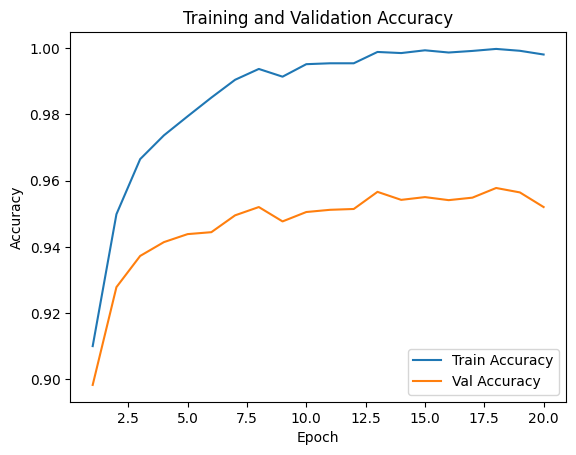

Best validation accuracy: 0.9577 at epoch 18
Test Accuracy for the best epoch with λ = 0.001: 0.8969
Lambda: 0.005
Epoch 1/20, Training Accuracy: 0.9141, Validation Accuracy: 0.9020
Epoch 2/20, Training Accuracy: 0.9450, Validation Accuracy: 0.9291
Epoch 3/20, Training Accuracy: 0.9514, Validation Accuracy: 0.9297
Epoch 4/20, Training Accuracy: 0.9631, Validation Accuracy: 0.9379
Epoch 5/20, Training Accuracy: 0.9680, Validation Accuracy: 0.9430
Epoch 6/20, Training Accuracy: 0.9721, Validation Accuracy: 0.9437
Epoch 7/20, Training Accuracy: 0.9736, Validation Accuracy: 0.9447
Epoch 8/20, Training Accuracy: 0.9738, Validation Accuracy: 0.9415
Epoch 9/20, Training Accuracy: 0.9781, Validation Accuracy: 0.9471
Epoch 10/20, Training Accuracy: 0.9753, Validation Accuracy: 0.9451
Epoch 11/20, Training Accuracy: 0.9776, Validation Accuracy: 0.9473
Epoch 12/20, Training Accuracy: 0.9779, Validation Accuracy: 0.9452
Epoch 13/20, Training Accuracy: 0.9782, Validation Accuracy: 0.9456
Epoch 14/2

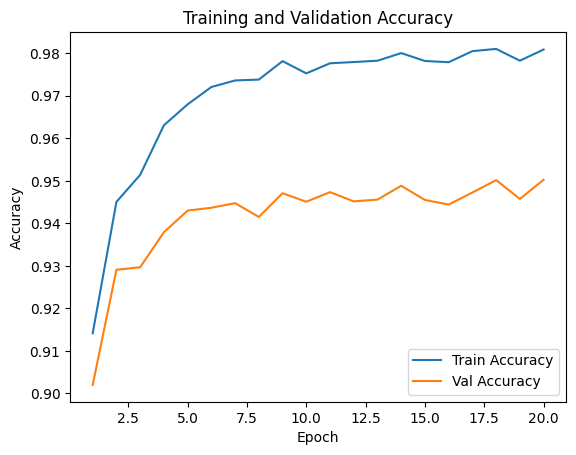

Best validation accuracy: 0.9503 at epoch 20
Test Accuracy for the best epoch with λ = 0.005: 0.8804
Lambda: 0.0008
Epoch 1/20, Training Accuracy: 0.9164, Validation Accuracy: 0.9038
Epoch 2/20, Training Accuracy: 0.9517, Validation Accuracy: 0.9302
Epoch 3/20, Training Accuracy: 0.9668, Validation Accuracy: 0.9343
Epoch 4/20, Training Accuracy: 0.9753, Validation Accuracy: 0.9389
Epoch 5/20, Training Accuracy: 0.9844, Validation Accuracy: 0.9441
Epoch 6/20, Training Accuracy: 0.9879, Validation Accuracy: 0.9447
Epoch 7/20, Training Accuracy: 0.9943, Validation Accuracy: 0.9513
Epoch 8/20, Training Accuracy: 0.9949, Validation Accuracy: 0.9480
Epoch 9/20, Training Accuracy: 0.9960, Validation Accuracy: 0.9508
Epoch 10/20, Training Accuracy: 0.9980, Validation Accuracy: 0.9501
Epoch 11/20, Training Accuracy: 0.9974, Validation Accuracy: 0.9528
Epoch 12/20, Training Accuracy: 0.9989, Validation Accuracy: 0.9543
Epoch 13/20, Training Accuracy: 0.9988, Validation Accuracy: 0.9518
Epoch 14/

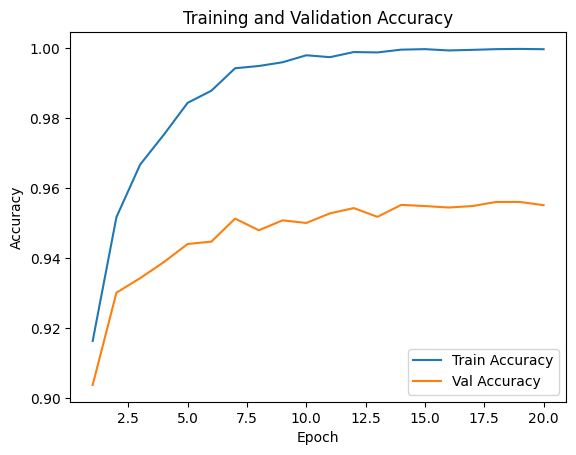

Best validation accuracy: 0.9561 at epoch 18
Test Accuracy for the best epoch with λ = 0.0008: 0.8981


In [14]:
for lam in [0.001, 0.005, 0.0008]:
    mlp_two_hidden = MLP(input_size=784, num_hidden_layers=2, hidden_size=256, output_size=10, activation="relu", l2_lambda=lam)

    # Run gradient check before training
    X_small = X_train[:3]
    y_small = y_train[:3]

    print(f"Lambda: {lam}")

    #mlp_two_hidden.gradient_check_full_layer(X_small, y_small, layer_idx=0)

    mlp_two_hidden.fit(X_train, y_train, X_valid, y_valid, lr=0.1, epochs=20, batch_size=64, optimizer="sgd")
    best_weights = mlp_two_hidden.weights
    best_biases = mlp_two_hidden.biases

    test_preds = mlp_two_hidden.predict(X_test)
    test_acc = mlp_two_hidden.evaluate_acc(y_test, test_preds)
    print(f"Test Accuracy for the best epoch with λ = {lam}: {test_acc:.4f}")

##3.4: CNN

###cnn with:
- 3 Convolutional layers (ReLU) + - 3 MaxPooling layers
- Flatten
- 2 fully connected (ReLU activations)
- {32, 64, 128, 256} hidden units in fullt connected layers
- Dropout after each fc layer
- 1 output layer (softmax)

In [15]:
X_tr = X_tr.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)
X_te  = X_te.reshape(-1, 28, 28, 1)

y_tr = y_tr.ravel()
y_val = y_val.ravel()
y_te  = y_te.ravel()

# Normalize pixel values to [0,1] range
X_tr = X_tr.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_te  = X_te.astype('float32')  / 255.0

def build_cnn(
    input_shape=(28, 28, 1),
    conv_filters=[32, 64, 64],
    kernel_size=(3, 3),
    pool_size=(2, 2),
    fc_units=64,
    dropout_rate=0.3
    ):
    """
    Creates a CNN with:
      - 3 Convolutional layers (ReLU)
      - 3 MaxPooling layers
      - Flatten
      - 2 Dense layers (ReLU)
      - Dropout after each Dense
      - 1 Dense output layer (softmax)
    """
    model = models.Sequential()

    # 1st Conv + Pool
    model.add(layers.Conv2D(conv_filters[0], kernel_size, activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=pool_size))

    # 2nd Conv + Pool
    model.add(layers.Conv2D(conv_filters[1], kernel_size, activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=pool_size))

    # 3rd Conv + Pool
    model.add(layers.Conv2D(conv_filters[2], kernel_size, activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=pool_size))

    # Flatten before Dense layers
    model.add(layers.Flatten())

    # Two fully connected (hidden) layers with ReLU activations
    model.add(layers.Dense(fc_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(fc_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))

    # Output layer (softmax)
    model.add(layers.Dense(10, activation='softmax'))

    # Compile
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 69ms/step - accuracy: 0.5455 - loss: 1.2887 - val_accuracy: 0.9165 - val_loss: 0.2779
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - accuracy: 0.9042 - loss: 0.3244 - val_accuracy: 0.9502 - val_loss: 0.1627
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.9409 - loss: 0.2001 - val_accuracy: 0.9524 - val_loss: 0.1577
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.9541 - loss: 0.1536 - val_accuracy: 0.9610 - val_loss: 0.1296
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 63ms/step - accuracy: 0.9657 - loss: 0.1160 - val_accuracy: 0.9647 - val_loss: 0.1214
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.9728 - loss: 0.0928 - val_accuracy: 0.9684 - val_loss: 0.1108
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - accuracy: 0.9766 - loss: 0.0807 - val_accuracy: 0.9627 - val_loss: 0.1387
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 63ms/step - accuracy: 0.9804 - loss: 0.0662 - 

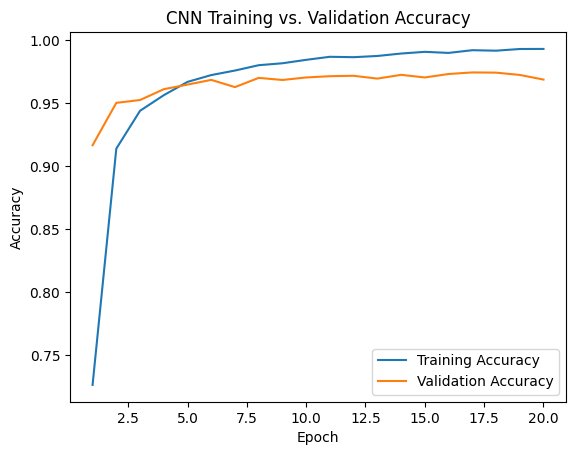

In [ ]:
# For testing
model = build_cnn(
    input_shape=(28, 28, 1),
    conv_filters=[32, 64, 128],
    kernel_size=(3, 3),
    pool_size=(2, 2),
    fc_units=64,
    dropout_rate=0.3
)

history = model.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val)
)


test_loss, test_acc = model.evaluate(X_te, y_te, verbose=0)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training vs. Validation Accuracy')
plt.legend()
plt.show()

###The CNN with different number of units in the hidden layers (fully connected)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.4444 - loss: 1.5386 - val_accuracy: 0.8831 - val_loss: 0.4016
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.8223 - loss: 0.5734 - val_accuracy: 0.9197 - val_loss: 0.2648
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.8872 - loss: 0.3801 - val_accuracy: 0.9456 - val_loss: 0.1845
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 63ms/step - accuracy: 0.9174 - loss: 0.2836 - val_accuracy: 0.9542 - val_loss: 0.1546
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.9338 - loss: 0.2303 - val_accuracy: 0.9567 - val_loss: 0.1456
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.9451 - loss: 0.1874 - val_accuracy: 0.9587 - val_loss: 0.1422
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 65ms/step - accuracy: 0.9522 - loss: 0.1672 - val_accuracy: 0.9643 - val_loss: 0.1332
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.9578 - loss: 0.1401 - 

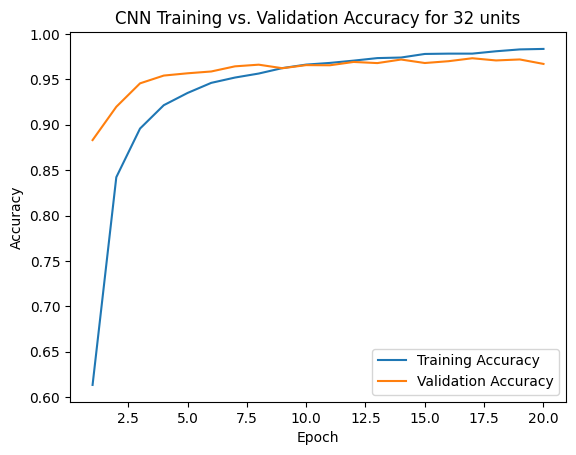

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.5234 - loss: 1.3531 - val_accuracy: 0.9143 - val_loss: 0.2839
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.8940 - loss: 0.3496 - val_accuracy: 0.9448 - val_loss: 0.1807
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.9355 - loss: 0.2228 - val_accuracy: 0.9523 - val_loss: 0.1594
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 66ms/step - accuracy: 0.9524 - loss: 0.1664 - val_accuracy: 0.9623 - val_loss: 0.1270
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.9631 - loss: 0.1284 - val_accuracy: 0.9637 - val_loss: 0.1200
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 69ms/step - accuracy: 0.9723 - loss: 0.0984 - val_accuracy: 0.9601 - val_loss: 0.1419
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 63ms/step - accuracy: 0.9761 - loss: 0.0860 - val_accuracy: 0.9656 - val_loss: 0.1192
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.9801 - loss: 0.0680 - 

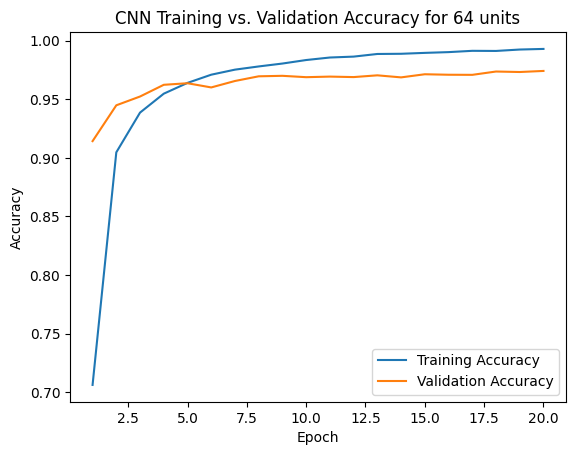

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.6002 - loss: 1.1580 - val_accuracy: 0.9254 - val_loss: 0.2326
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.9232 - loss: 0.2524 - val_accuracy: 0.9530 - val_loss: 0.1481
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.9513 - loss: 0.1599 - val_accuracy: 0.9596 - val_loss: 0.1293
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 65ms/step - accuracy: 0.9629 - loss: 0.1259 - val_accuracy: 0.9629 - val_loss: 0.1211
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - accuracy: 0.9715 - loss: 0.0918 - val_accuracy: 0.9688 - val_loss: 0.1041
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 69ms/step - accuracy: 0.9784 - loss: 0.0715 - val_accuracy: 0.9689 - val_loss: 0.1075
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.9807 - loss: 0.0641 - val_accuracy: 0.9706 - val_loss: 0.1074
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.9843 - loss: 0.0530 - 

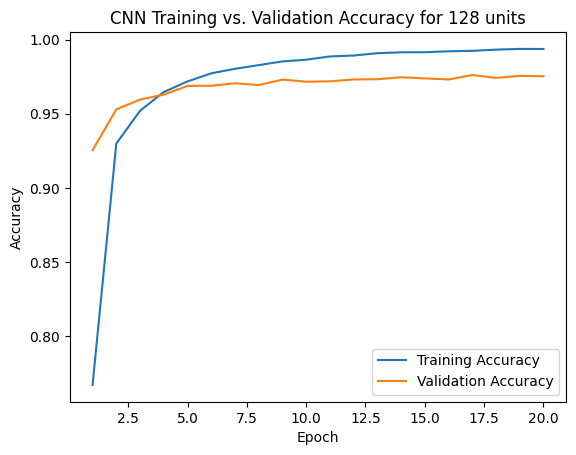

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - accuracy: 0.6401 - loss: 1.0381 - val_accuracy: 0.9321 - val_loss: 0.2162
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.9310 - loss: 0.2290 - val_accuracy: 0.9561 - val_loss: 0.1393
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 68ms/step - accuracy: 0.9576 - loss: 0.1375 - val_accuracy: 0.9626 - val_loss: 0.1235
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 70ms/step - accuracy: 0.9673 - loss: 0.1033 - val_accuracy: 0.9668 - val_loss: 0.1117
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 65ms/step - accuracy: 0.9747 - loss: 0.0803 - val_accuracy: 0.9725 - val_loss: 0.0935
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 69ms/step - accuracy: 0.9806 - loss: 0.0606 - val_accuracy: 0.9718 - val_loss: 0.0935
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - accuracy: 0.9839 - loss: 0.0523 - val_accuracy: 0.9717 - val_loss: 0.0995
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - accuracy: 0.9873 - loss: 0.0420 - 

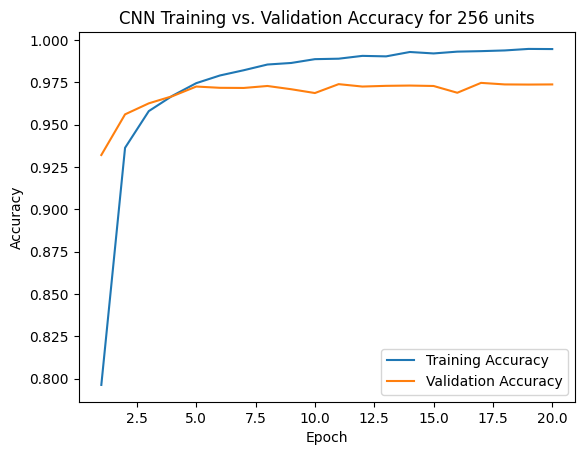

In [ ]:
for fc_unit in [32,64,128,256]:
    model = build_cnn(
        input_shape=(28, 28, 1),
        conv_filters=[32, 64, 128],
        kernel_size=(3,3),
        pool_size=(2,2),
        fc_units=fc_unit,
        dropout_rate=0.3
    )

    history = model.fit(
        X_tr, y_tr,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, y_val)
    )


    test_loss, test_acc = model.evaluate(X_te, y_te, verbose=0)
    print(f"\nTest loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs_range = range(1, len(acc) + 1)

    plt.figure()
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'CNN Training vs. Validation Accuracy for {fc_unit} units')
    plt.legend()
    plt.show()

###CNN with different droput rates:

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 69ms/step - accuracy: 0.7026 - loss: 0.8899 - val_accuracy: 0.9283 - val_loss: 0.2248
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.9425 - loss: 0.1787 - val_accuracy: 0.9495 - val_loss: 0.1561
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.9645 - loss: 0.1121 - val_accuracy: 0.9603 - val_loss: 0.1236
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.9760 - loss: 0.0764 - val_accuracy: 0.9557 - val_loss: 0.1508
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 66ms/step - accuracy: 0.9809 - loss: 0.0593 - val_accuracy: 0.9672 - val_loss: 0.1097
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.9870 - loss: 0.0421 - val_accuracy: 0.9675 - val_loss: 0.1092
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 69ms/step - accuracy: 0.9891 - loss: 0.0344 - val_accuracy: 0.9705 - val_loss: 0.1025
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.9903 - loss: 0.0279 - 

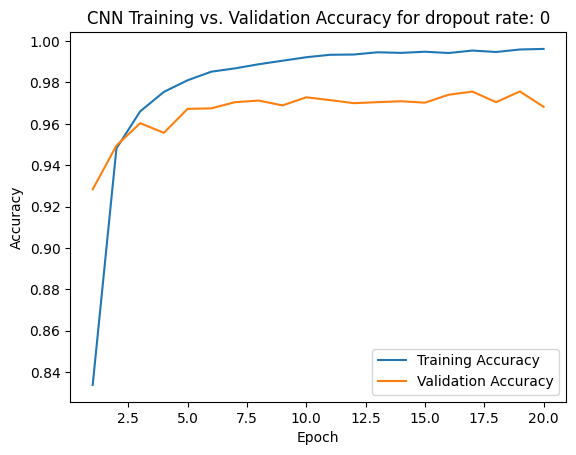

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.6821 - loss: 0.9252 - val_accuracy: 0.9338 - val_loss: 0.2104
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.9410 - loss: 0.1896 - val_accuracy: 0.9557 - val_loss: 0.1413
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.9647 - loss: 0.1131 - val_accuracy: 0.9593 - val_loss: 0.1278
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 66ms/step - accuracy: 0.9758 - loss: 0.0777 - val_accuracy: 0.9665 - val_loss: 0.1072
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.9813 - loss: 0.0569 - val_accuracy: 0.9682 - val_loss: 0.1047
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 0.9860 - loss: 0.0453 - val_accuracy: 0.9688 - val_loss: 0.1062
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.9872 - loss: 0.0377 - val_accuracy: 0.9676 - val_loss: 0.1165
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.9900 - loss: 0.0320 - 

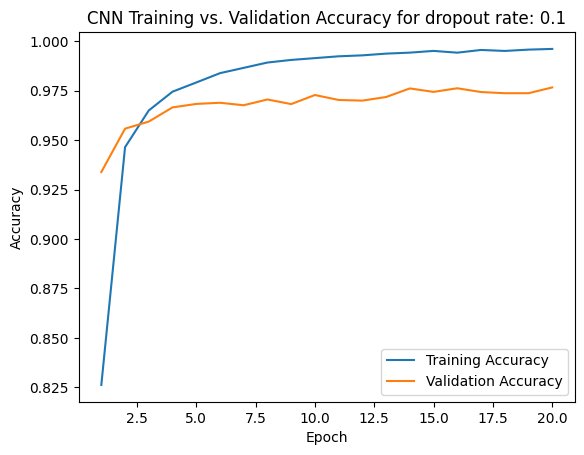

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 54s 70ms/step - accuracy: 0.6684 - loss: 0.9745 - val_accuracy: 0.9367 - val_loss: 0.2038
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 69ms/step - accuracy: 0.9413 - loss: 0.1931 - val_accuracy: 0.9552 - val_loss: 0.1404
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.9626 - loss: 0.1196 - val_accuracy: 0.9638 - val_loss: 0.1143
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.9737 - loss: 0.0833 - val_accuracy: 0.9675 - val_loss: 0.1084
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 84s 69ms/step - accuracy: 0.9787 - loss: 0.0675 - val_accuracy: 0.9680 - val_loss: 0.1010
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.9840 - loss: 0.0509 - val_accuracy: 0.9676 - val_loss: 0.1191
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.9878 - loss: 0.0394 - val_accuracy: 0.9740 - val_loss: 0.0932
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.9884 - loss: 0.0357 - 

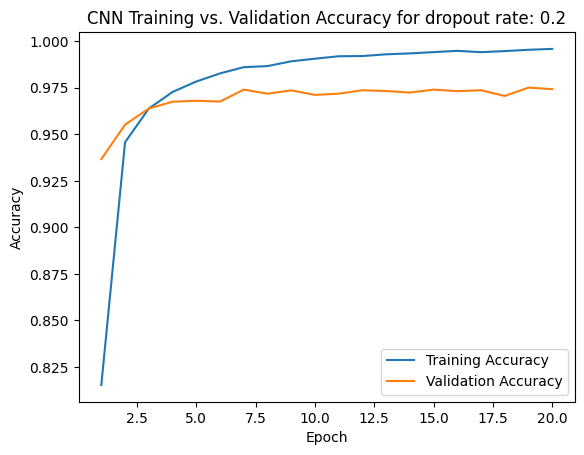

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.6390 - loss: 1.0315 - val_accuracy: 0.9360 - val_loss: 0.2086
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 67ms/step - accuracy: 0.9307 - loss: 0.2202 - val_accuracy: 0.9572 - val_loss: 0.1364
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 71ms/step - accuracy: 0.9559 - loss: 0.1415 - val_accuracy: 0.9613 - val_loss: 0.1294
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.9700 - loss: 0.0961 - val_accuracy: 0.9693 - val_loss: 0.1021
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - accuracy: 0.9748 - loss: 0.0797 - val_accuracy: 0.9699 - val_loss: 0.0978
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.9818 - loss: 0.0582 - val_accuracy: 0.9672 - val_loss: 0.1122
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 69ms/step - accuracy: 0.9842 - loss: 0.0488 - val_accuracy: 0.9722 - val_loss: 0.0986
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 67ms/step - accuracy: 0.9875 - loss: 0.0389 - 

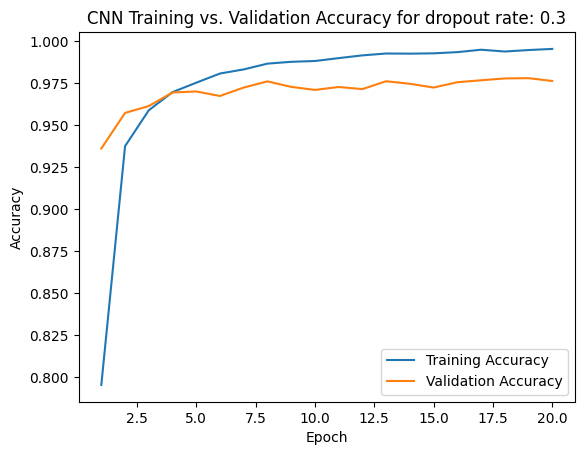

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 56s 73ms/step - accuracy: 0.6402 - loss: 1.0534 - val_accuracy: 0.9217 - val_loss: 0.2444
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.9285 - loss: 0.2362 - val_accuracy: 0.9503 - val_loss: 0.1575
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.9556 - loss: 0.1482 - val_accuracy: 0.9609 - val_loss: 0.1239
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.9674 - loss: 0.1094 - val_accuracy: 0.9663 - val_loss: 0.1115
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 69ms/step - accuracy: 0.9732 - loss: 0.0876 - val_accuracy: 0.9687 - val_loss: 0.1059
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - accuracy: 0.9789 - loss: 0.0690 - val_accuracy: 0.9707 - val_loss: 0.1005
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - accuracy: 0.9836 - loss: 0.0551 - val_accuracy: 0.9663 - val_loss: 0.1303
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.9866 - loss: 0.0448 - 

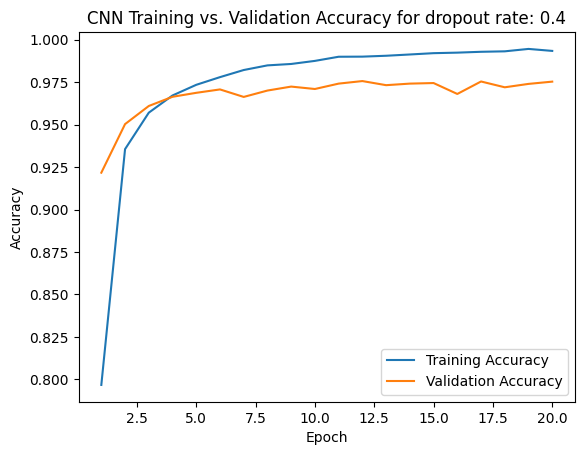

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.5943 - loss: 1.1563 - val_accuracy: 0.9342 - val_loss: 0.2167
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 67ms/step - accuracy: 0.9255 - loss: 0.2472 - val_accuracy: 0.9532 - val_loss: 0.1557
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - accuracy: 0.9532 - loss: 0.1530 - val_accuracy: 0.9603 - val_loss: 0.1318
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 73ms/step - accuracy: 0.9676 - loss: 0.1069 - val_accuracy: 0.9652 - val_loss: 0.1174
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 68ms/step - accuracy: 0.9742 - loss: 0.0861 - val_accuracy: 0.9668 - val_loss: 0.1115
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - accuracy: 0.9776 - loss: 0.0726 - val_accuracy: 0.9711 - val_loss: 0.1057
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.9838 - loss: 0.0565 - val_accuracy: 0.9719 - val_loss: 0.0989
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 73ms/step - accuracy: 0.9847 - loss: 0.0487 - 

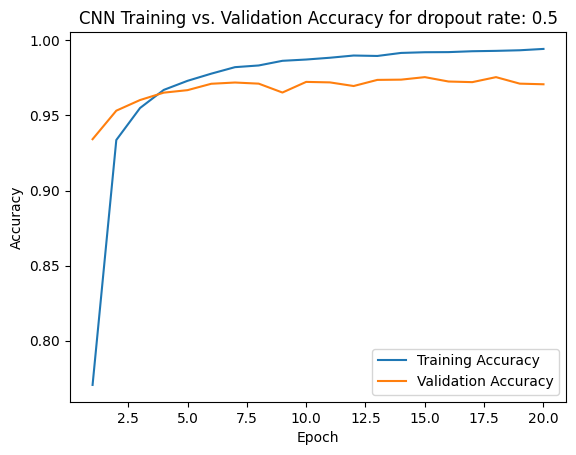

In [ ]:
for do_rate in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    model = build_cnn(
        input_shape=(28, 28, 1),
        conv_filters=[32, 64, 128],
        kernel_size=(3,3),
        pool_size=(2,2),
        fc_units=256,
        dropout_rate=do_rate
    )

    history = model.fit(
        X_tr, y_tr,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, y_val)
    )


    test_loss, test_acc = model.evaluate(X_te, y_te, verbose=0)
    print(f"\nTest loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs_range = range(1, len(acc) + 1)

    plt.figure()
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'CNN Training vs. Validation Accuracy for dropout rate: {do_rate}')
    plt.legend()
    plt.show()
